# **Name: Suraj Singh Chauhan**
# Repo Link:- https://github.com/surajra123/EDA_Optimising_NYC_Taxis_Suraj_Singh_Chauhan.zip

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings

In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

# df = pd.read_parquet('2023-12.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe faor the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/content/Assignments/EDA/data_NYC_Taxi/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        if file_name.endswith(".parquet"):
            month_df = pd.read_parquet(file_path)
        elif file_name.endswith(".csv"):
           month_df = pd.read_csv(file_path)
        else:
          continue

        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])
        month_df['date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['hour'] = month_df['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = month_df.groupby(['date', 'hour'], group_keys=False).sample(frac=0.05, random_state=42)

        # Iterate through each date and hour

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
# df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [8]:
# Store the df in csv/parquet
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df.to_parquet('sample_taxi_data.parquet')


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

**Now** we can load the new data directly.

In [9]:
# Load the new data file
df=pd.read_parquet('sample_taxi_data.parquet')

In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee,Unnamed: 0.1,Unnamed: 0
0,2,2023-08-31 23:56:01,2023-09-01 00:18:41,1.0,3.11,1.0,N,114,246,1,...,0.00,1.0,26.20,2.5,0.00,2023-08-31,23,NaN,NaN,NaN
1,2,2023-09-01 00:22:07,2023-09-01 00:49:44,1.0,6.85,1.0,N,144,238,1,...,0.00,1.0,45.72,2.5,0.00,2023-09-01,0,NaN,NaN,NaN
2,2,2023-09-01 00:40:20,2023-09-01 00:51:30,1.0,1.15,1.0,N,230,162,1,...,0.00,1.0,19.68,2.5,0.00,2023-09-01,0,NaN,NaN,NaN
3,2,2023-09-01 00:29:50,2023-09-01 01:06:41,2.0,19.82,2.0,N,132,142,1,...,6.94,1.0,99.23,2.5,1.75,2023-09-01,0,NaN,NaN,NaN
4,2,2023-09-01 00:07:05,2023-09-01 00:13:37,2.0,1.22,1.0,N,186,107,1,...,0.00,1.0,14.60,2.5,0.00,2023-09-01,0,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036619 entries, 0 to 2036618
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed
df=df.reset_index(drop=True)
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee,Unnamed: 0.1,Unnamed: 0
0,2,2023-08-31 23:56:01,2023-09-01 00:18:41,1.0,3.11,1.0,N,114,246,1,...,0.00,1.0,26.20,2.5,0.00,2023-08-31,23,NaN,NaN,NaN
1,2,2023-09-01 00:22:07,2023-09-01 00:49:44,1.0,6.85,1.0,N,144,238,1,...,0.00,1.0,45.72,2.5,0.00,2023-09-01,0,NaN,NaN,NaN
2,2,2023-09-01 00:40:20,2023-09-01 00:51:30,1.0,1.15,1.0,N,230,162,1,...,0.00,1.0,19.68,2.5,0.00,2023-09-01,0,NaN,NaN,NaN
3,2,2023-09-01 00:29:50,2023-09-01 01:06:41,2.0,19.82,2.0,N,132,142,1,...,6.94,1.0,99.23,2.5,1.75,2023-09-01,0,NaN,NaN,NaN
4,2,2023-09-01 00:07:05,2023-09-01 00:13:37,2.0,1.22,1.0,N,186,107,1,...,0.00,1.0,14.60,2.5,0.00,2023-09-01,0,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# Combine the two airport fee columns
if 'airport_fee' in df.columns and 'Airport_fee' in df.columns:
    df['airport_fee'] = df['airport_fee'].fillna(0) + df['Airport_fee'].fillna(0)
    df.drop(columns=['Airport_fee'], inplace=True)
    print("Columns combined successfully.")


Columns combined successfully.


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative
(df['fare_amount'] < 0).sum()
print(df[df['fare_amount'] < 0][['fare_amount', 'RatecodeID', 'trip_distance']])

Empty DataFrame
Columns: [fare_amount, RatecodeID, trip_distance]
Index: []


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
df.loc[df['fare_amount'] < 0, 'RatecodeID'].value_counts()

,count
RatecodeID,


In [17]:
# Find which columns have negative values
df.select_dtypes(include=['number']).lt(0).any()

,0
VendorID,False
passenger_count,False
trip_distance,False
RatecodeID,False
PULocationID,False
DOLocationID,False
payment_type,False
fare_amount,False
extra,True
mta_tax,True


In [18]:
# fix these negative values
df = df[(df['fare_amount'] >= 0) & (df['total_amount'] >= 0)]

# removed all the negative values
df.select_dtypes(include=['number']).lt(0).any()


,0
VendorID,False
passenger_count,False
trip_distance,False
RatecodeID,False
PULocationID,False
DOLocationID,False
payment_type,False
fare_amount,False
extra,False
mta_tax,False


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [19]:
# Find the proportion of missing values in each column
missing_val=(df.isna().sum() / len(df) * 100)
missing_val

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,3.417344
trip_distance,0.000000
RatecodeID,3.417344
store_and_fwd_flag,3.417344
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
null_val = (df['passenger_count'].isna().sum())
impute_val = (df['passenger_count'].fillna(df['passenger_count'].median()))
impute_val


,passenger_count
0,1.0
1,1.0
2,1.0
3,2.0
4,2.0
...,...
2036614,1.0
2036615,1.0
2036616,1.0
2036617,2.0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [21]:
# Fix missing values in 'RatecodeID'
missing_val_rateID = (df['RatecodeID'].isna().sum())
df['RatecodeID'] = df['RatecodeID'].fillna(1)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [22]:
# handle null values in congestion_surcharge
df['congestion_surcharge'].isnull().sum()
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
df['congestion_surcharge']

,congestion_surcharge
0,2.5
1,2.5
2,2.5
3,2.5
4,2.5
...,...
2036614,0.0
2036615,2.5
2036616,2.5
2036617,2.5


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [23]:
# Handle any remaining missing values



### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [24]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df[['trip_distance', 'fare_amount', 'passenger_count', 'total_amount']].describe()



,trip_distance,fare_amount,passenger_count,total_amount
count,2.036523e+06,2.036523e+06,1.966928e+06,2.036523e+06
mean,3.946072e+00,1.989647e+01,1.369664e+00,2.897331e+01
std,1.658088e+02,1.835740e+01,8.927075e-01,2.293438e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.050000e+00,9.300000e+00,1.000000e+00,1.596000e+01
50%,1.800000e+00,1.350000e+01,1.000000e+00,2.100000e+01
75%,3.400000e+00,2.221000e+01,1.000000e+00,3.100000e+01
max,1.439264e+05,1.116700e+03,9.000000e+00,1.120700e+03


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [25]:
# remove passenger_count > 6
print(f"length: {len(df)}")
(df['passenger_count'] > 6).sum()
df = df[(df['passenger_count'] <= 6)]
df['passenger_count'].value_counts().sort_index()

length: 2036523


,count
passenger_count,
0.0,31377
1.0,1479680
2.0,297446
3.0,73796
4.0,41892
5.0,25954
6.0,16763


In [26]:
# Continue with outlier handling
print(f"before length: {len(df)}")
df = df[df['trip_distance'] <= 150]

df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0))]
print(f"after length: {len(df)}")
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
print(f"\nData types:\n{df.dtypes}")

before length: 1966908
after length: 1966560

Data types:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
date                             object
hour                              int32
airport_fee                     float64
Unnamed: 0.1                    float64
Unnamed: 0                      float64
trip_duration         

In [27]:
# Do any columns need standardising?
# print(df.info())
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

if 'passenger_count' in df.columns:
    df=df[df['passenger_count'] > 0]

print('Data cleaned. Shape:', df.shape)
print('Missing values per column:')
print(df.isnull().sum())

Data cleaned. Shape: (1935197, 23)
Missing values per column:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count                0
trip_distance                  0
RatecodeID                     0
store_and_fwd_flag             0
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge           0
date                           0
hour                           0
airport_fee                    0
Unnamed: 0.1             1896654
trip_duration                  0
dtype: int64


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [28]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'date',
 'hour',
 'airport_fee',
 'Unnamed: 0.1',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [29]:
print("VARIABLES")

print("\nCATEGORICAL :")
categories = [
    'vendorID',
    'RatecodeID',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'payment_type'
]
for var in categories:
    print(f"- {var}")

print("\nNUMERICAL :")
numericals = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'trip_duration'
]
for var in numericals:
    print(f"- {var}")

print("\nMONETARY PARAMETERS :")
monetary = [
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee',
    'fare_amount'
]
for var in monetary:
    print(f"- {var}")

VARIABLES

CATEGORICAL :
- vendorID
- RatecodeID
- tpep_pickup_datetime
- tpep_dropoff_datetime
- PULocationID
- DOLocationID
- payment_type

NUMERICAL :
- passenger_count
- trip_distance
- fare_amount
- trip_duration

MONETARY PARAMETERS :
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- airport_fee
- fare_amount


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

tpep_pickup_datetime
0      54218
1      36339
2      23899
3      15645
4      10179
5      10839
6      26006
7      51434
8      71828
9      82457
10     90183
11     98023
12    106432
13    109602
14    117513
15    120447
16    120789
17    130831
18    136823
19    122784
20    109770
21    109192
22    100713
23     79251
Name: tpep_pickup_datetime, dtype: int64


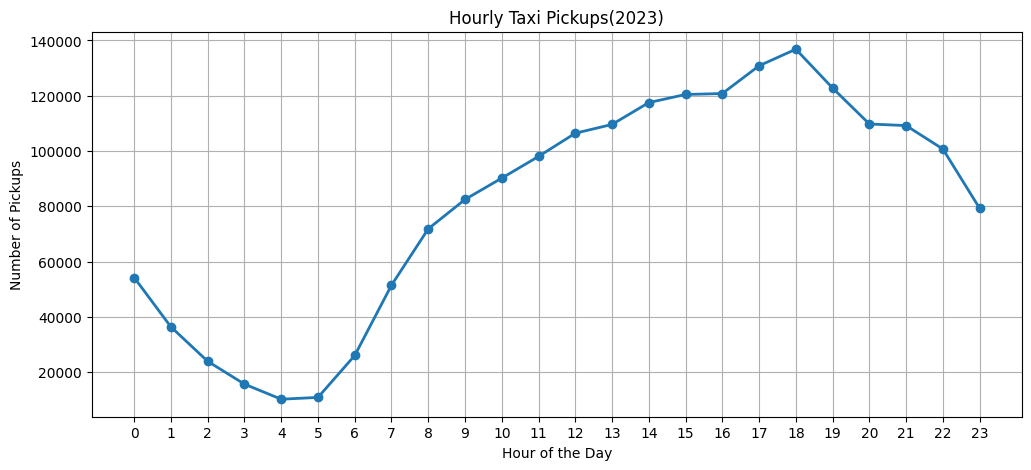

In [30]:
# Find and show the hourly trends in taxi pickups
hourly_trend = df.groupby(df['tpep_pickup_datetime'].dt.hour)['tpep_pickup_datetime'].size()
print(hourly_trend)
plt.figure(figsize=(12, 5))
plt.plot(hourly_trend.index, hourly_trend, marker='o', linewidth=2)
plt.title('Hourly Taxi Pickups(2023)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

   pickup_week pickup_day  pickups
0            0     Monday   242026
1            1    Tuesday   281090
2            2  Wednesday   297808
3            3   Thursday   303669
4            4     Friday   287234
5            5   Saturday   280826
6            6     Sunday   242544


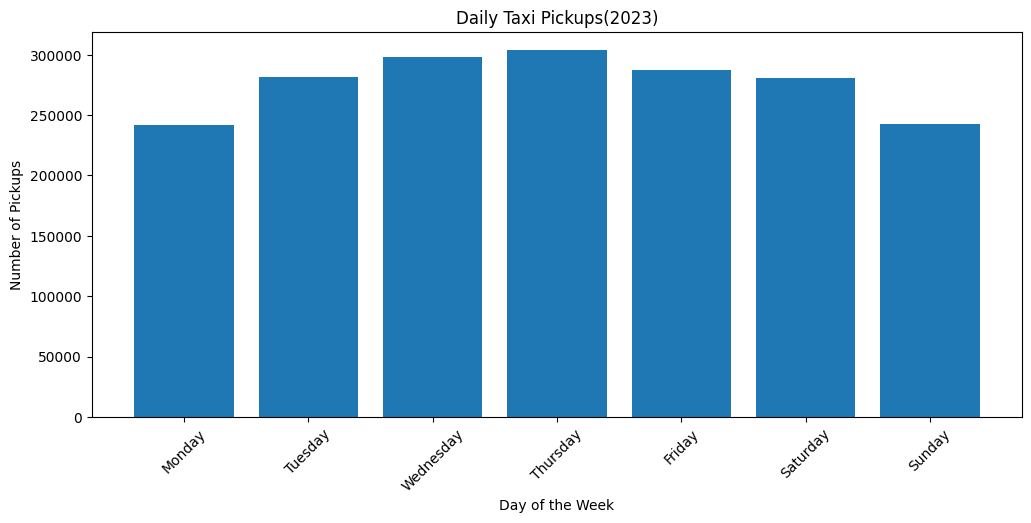

In [31]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_week'] = df['tpep_pickup_datetime'].dt.dayofweek
daily_trend = df.groupby(['pickup_week','pickup_day']).size().reset_index(name='pickups')
print(daily_trend)

plt.figure(figsize=(12, 5))
plt.bar(range(7), daily_trend['pickups'])
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.title('Daily Taxi Pickups(2023)')
plt.xticks(range(7), daily_trend['pickup_day'], rotation=45)
# plt.grid(True)
plt.show()

    pickup_month  pickups month_name
0              1   161304        Jan
1              2   152829        Feb
2              3   178500        Mar
3              4   171892        Apr
4              5   174634        May
5              6   164214        Jun
6              7   144496        Jul
7              8   140276        Aug
8              9   145576        Sep
9             10   172944        Oct
10            11   164706        Nov
11            12   163826        Dec


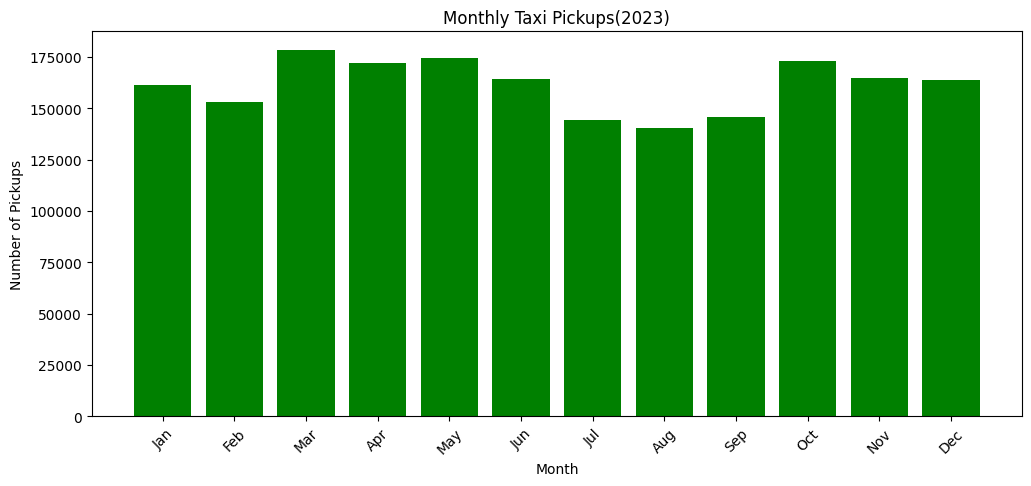

In [32]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
monthly_trend = df.groupby(['pickup_month']).size().reset_index(name='pickups')
month_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_trend['month_name'] = monthly_trend['pickup_month'].apply(lambda x: month_name[x-1])
print(monthly_trend)

plt.figure(figsize=(12, 5))
plt.bar(monthly_trend['month_name'], monthly_trend['pickups'], color='green')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Taxi Pickups(2023)')
plt.xticks(rotation=45)
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [33]:
# Analyse the above parameters
parameters = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
for param in parameters:
    print(f"\nParameter: {param}")
    zero_count = (df[param] == 0).sum()
    print(f"Zero value: {zero_count}")
    negatve_count = (df[param] < 0).sum()
    print(f"Negative value: {negatve_count}")


Parameter: fare_amount
Zero value: 266
Negative value: 0

Parameter: tip_amount
Zero value: 431294
Negative value: 0

Parameter: total_amount
Zero value: 98
Negative value: 0

Parameter: trip_distance
Zero value: 22747
Negative value: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [34]:
# Create a df with non zero entries for the selected parameters.
df_nonzero = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)].copy()
print(f"Dataset: {len(df)}")
print(f"Rows: {len(df_nonzero)}")
print(f"Zero values removed: {len(df) - len(df_nonzero)}")

df_tips = df_nonzero[df_nonzero['tip_amount'] > 0].copy()
print(f"\nTips dataset: {len(df_tips)}")
print(f"Zero values removed: {len(df_nonzero) - len(df_tips)}")
print(df_nonzero[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe())

Dataset: 1935197
Rows: 1934931
Zero values removed: 266

Tips dataset: 1503894
Zero values removed: 431037
        fare_amount    tip_amount  total_amount  trip_distance
count  1.934931e+06  1.934931e+06  1.934931e+06   1.934931e+06
mean   1.984932e+01  3.591817e+00  2.900339e+01   3.469210e+00
std    1.849182e+01  4.098145e+00  2.312627e+01   4.580949e+00
min    1.000000e-02  0.000000e+00  1.010000e+00   0.000000e+00
25%    9.300000e+00  1.000000e+00  1.596000e+01   1.060000e+00
50%    1.350000e+01  2.860000e+00  2.100000e+01   1.790000e+00
75%    2.190000e+01  4.470000e+00  3.080000e+01   3.400000e+00
max    1.116700e+03  4.100000e+02  1.120700e+03   1.460900e+02


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

   month_name  Total revenue  Avg rate  Num trips
0         Jan     4439918.95     27.53     161286
1         Feb     4171616.59     27.30     152807
2         Mar     5063765.35     28.37     178473
3         Apr     4942564.65     28.76     171866
4         May     5151200.12     29.50     174615
5         Jun     4829328.25     29.41     164194
6         Jul     4218057.13     29.20     144475
7         Aug     4107013.04     29.28     140258
8         Sep     4408759.90     30.29     145555
9         Oct     5144153.54     29.75     172924
10        Nov     4842098.65     29.40     164682
11        Dec     4801087.16     29.31     163796


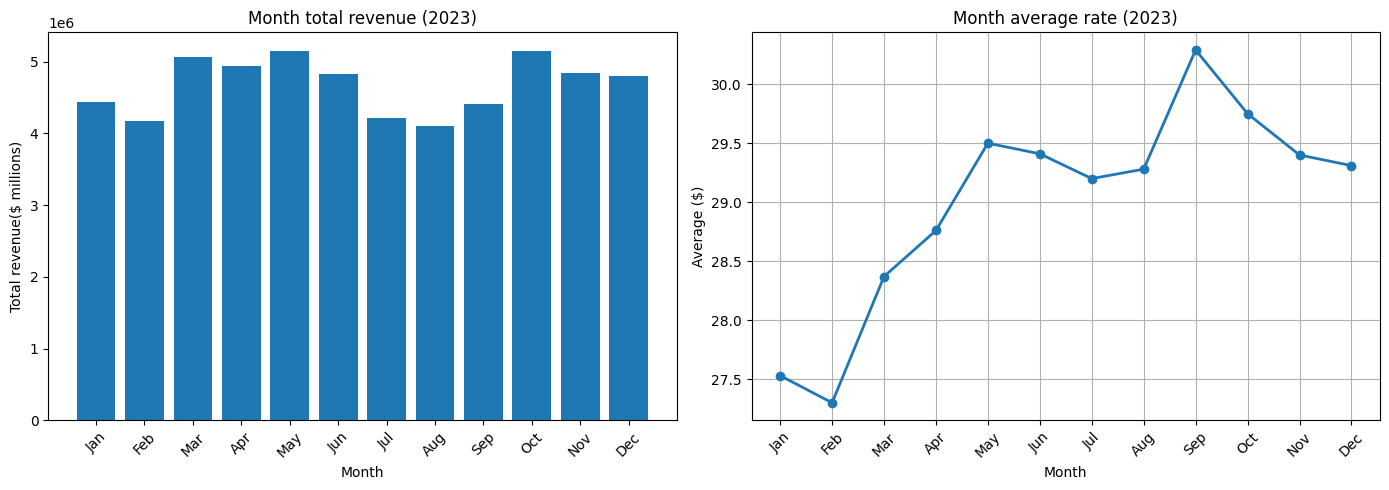

In [35]:
# Group data by month and analyse monthly revenue
month_revenue = df_nonzero.groupby('pickup_month').agg({
    'total_amount': ['sum', 'mean', 'count']
}).round(2)
month_revenue.columns = ['Total revenue', 'Avg rate', 'Num trips']
month_revenue=month_revenue.reset_index()
month_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue['month_name'] = month_revenue['pickup_month'].apply(lambda x: month_name[x-1])
print(month_revenue[['month_name', 'Total revenue', 'Avg rate', 'Num trips']])

#total revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(month_revenue['month_name'], month_revenue['Total revenue'])
axes[0].set(title='Month total revenue (2023)', xlabel='Month', ylabel='Total revenue($ millions)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(month_revenue['month_name'], month_revenue['Avg rate'], marker='o', linewidth=2)
axes[1].set(title='Month average rate (2023)', xlabel='Month', ylabel='Average ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid()

plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Q1 (jan-mar): $13.68M
Q2 (apr-jun): $14.92M
Q3 (jul-sep): $12.73M
Q4 (oct-dec): $14.79M


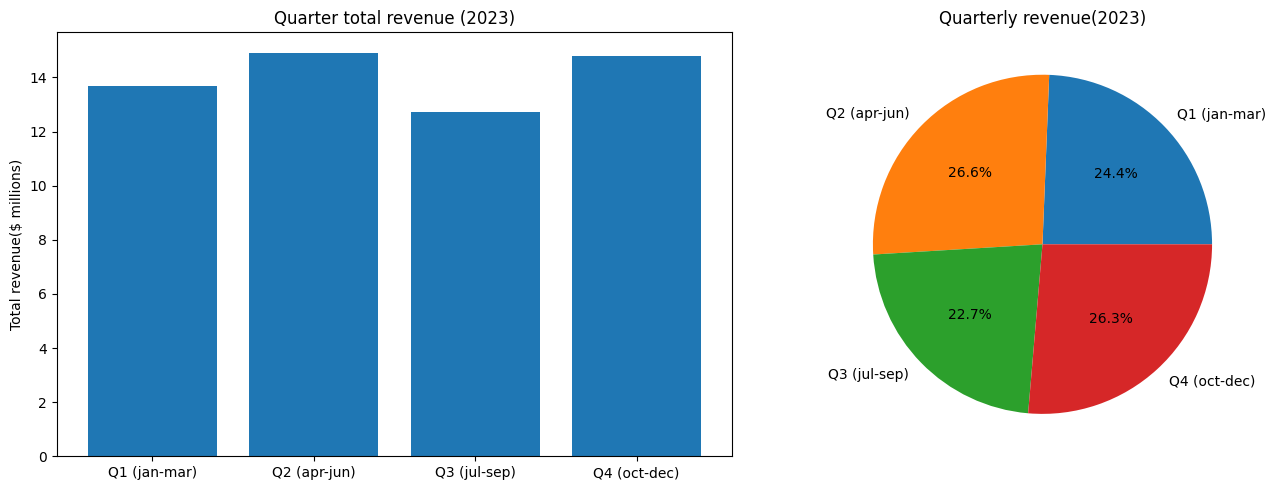

In [36]:
# Calculate proportion of each quarter
df_nonzero['quater'] = df_nonzero['pickup_month'].apply(lambda x: (x-1)//3+1)
quater_revenue=df_nonzero.groupby('quater')['total_amount'].sum()
quater_label = ['Q1 (jan-mar)', 'Q2 (apr-jun)', 'Q3 (jul-sep)', 'Q4 (oct-dec)']
for quater in range(1,5):
  revenue=quater_revenue[quater]
  print(f"{quater_label[quater-1]}: ${revenue/1e6:.2f}M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(quater_label, quater_revenue/1e6)
axes[0].set(title='Quarter total revenue (2023)', ylabel='Total revenue($ millions)')


axes[1].pie(quater_revenue, labels=quater_label, autopct='%1.1f%%')
axes[1].set(title='Quarterly revenue(2023)')

plt.tight_layout()
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


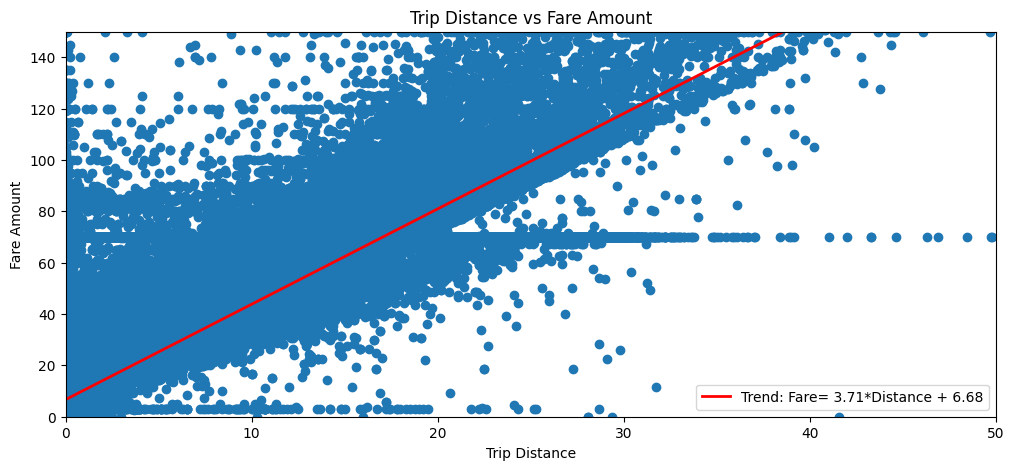

Correlation: 0.9446055434903349


In [37]:
# Show how trip fare is affected by distance

df_trip_fare = df_nonzero[df_nonzero['trip_distance'] > 0].copy()
correlation = df_trip_fare['trip_distance'].corr(df_trip_fare['fare_amount'])

plt.figure(figsize=(12, 5))
plt.scatter(df_trip_fare['trip_distance'], df_trip_fare['fare_amount'])
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')
plt.xlim(0,50)
plt.ylim(0,150)

# trend line
z=np.polyfit(df_trip_fare['trip_distance'], df_trip_fare['fare_amount'], 1)
p=np.poly1d(z)
x_axis=np.linspace(0,50,100)
plt.plot(x_axis, p(x_axis),"r-", linewidth=2, label=f'Trend: Fare= {z[0]:.2f}*Distance + {z[1]:.2f}')
plt.legend()
plt.show()

print(f"Correlation: {correlation}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

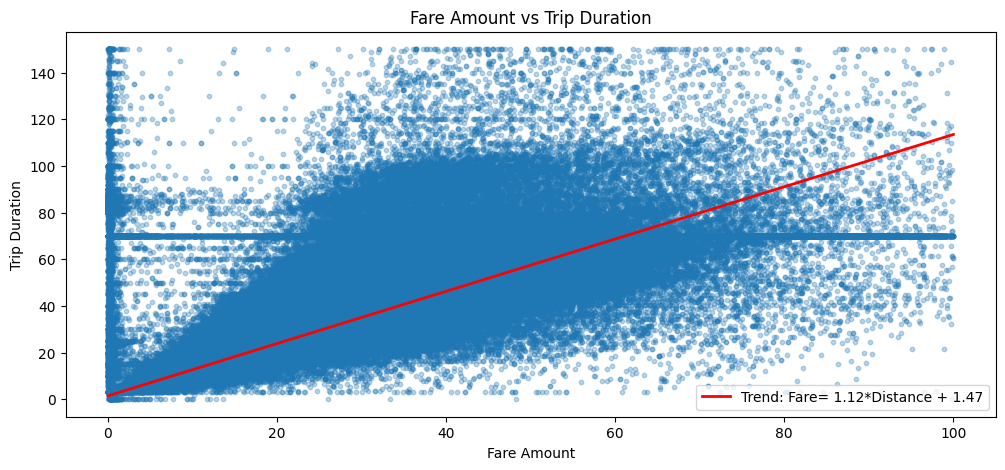

Correlation: 0.26653614664805814


In [38]:
# Show relationship between fare and trip duration

correlation_duration = df_nonzero['trip_duration'].corr(df_nonzero['fare_amount'])
plt.figure(figsize=(12, 5))

filter_data = df_nonzero[(df_nonzero['trip_duration'] > 0) &
                         (df_nonzero['trip_duration'] <= 100) &
                         (df_nonzero['fare_amount'] <= 150)]

plt.scatter(filter_data['trip_duration'], filter_data['fare_amount'], alpha=0.3, s=10)
plt.xlabel('Fare Amount')
plt.ylabel('Trip Duration')
plt.title('Fare Amount vs Trip Duration')

z=np.polyfit(filter_data['trip_duration'], filter_data['fare_amount'],1)
p=np.poly1d(z)
x_axis=np.linspace(0,100,100)
plt.plot(x_axis, p(x_axis),"r-", linewidth=2, label=f'Trend: Fare= {z[0]:.2f}*Distance + {z[1]:.2f}')
plt.legend()
plt.show()

print(f"Correlation: {correlation_duration}")



                 Mean fare  Median fare  Num trips
passenger_count                                   
1.0                  19.16         13.5    1479154
2.0                  22.25         14.2     297386
3.0                  22.02         14.2      73787
4.0                  24.07         14.9      41889
5.0                  19.12         13.5      25954
6.0                  19.40         13.5      16761


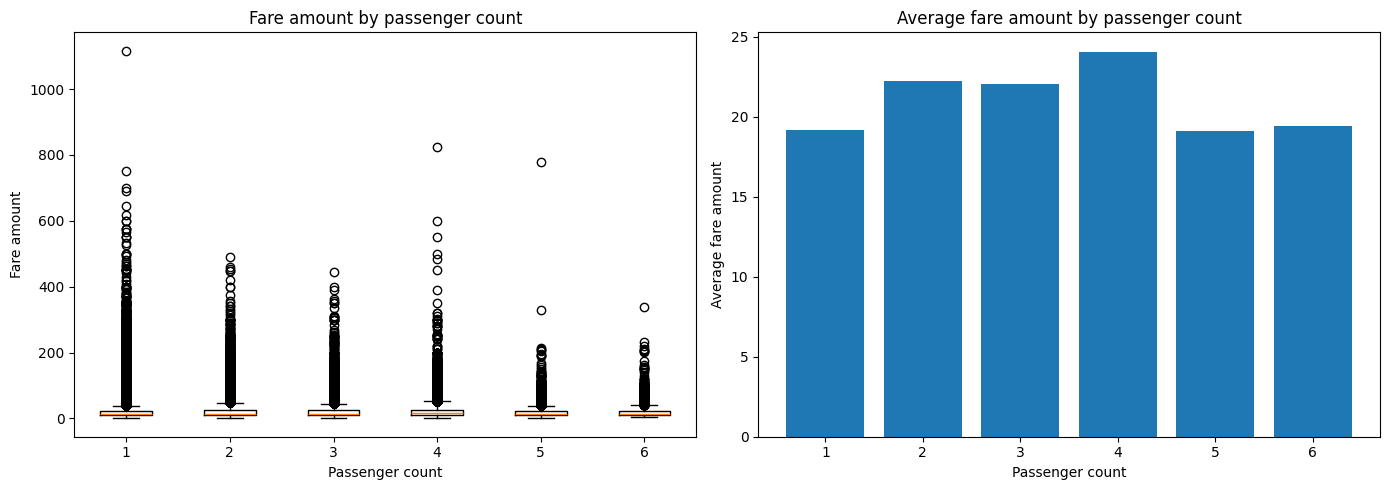


Correlation: 0.04598072981804095


In [39]:
# Show relationship between fare and number of passengers
correlation_passenger = df_nonzero['passenger_count'].corr(df_nonzero['fare_amount'])

fare_passenger = df_nonzero.groupby('passenger_count').agg({
    'fare_amount': ['mean', 'median', 'count']
}).round(2)

fare_passenger.columns = ['Mean fare', 'Median fare', 'Num trips']
print(fare_passenger)

fig, axes = plt.subplots(1,2, figsize=(14, 5))

data_plot=[df_nonzero[df_nonzero['passenger_count'] == i]['fare_amount'].values
           for i in range(1,7)]
axes[0].boxplot(data_plot, label=range(1,7))
axes[0].set(xlabel='Passenger count', ylabel='Fare amount', title='Fare amount by passenger count')


avg_fare_passenger=[df_nonzero[df_nonzero['passenger_count']==i]['fare_amount'].mean()
for i in range(1,7)]
axes[1].bar(range(1,7), avg_fare_passenger)
axes[1].set(xlabel='Passenger count', ylabel='Average fare amount', title='Average fare amount by passenger count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

print(f"\nCorrelation: {correlation_passenger}")

/tmp/ipykernel_6808/3217947460.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


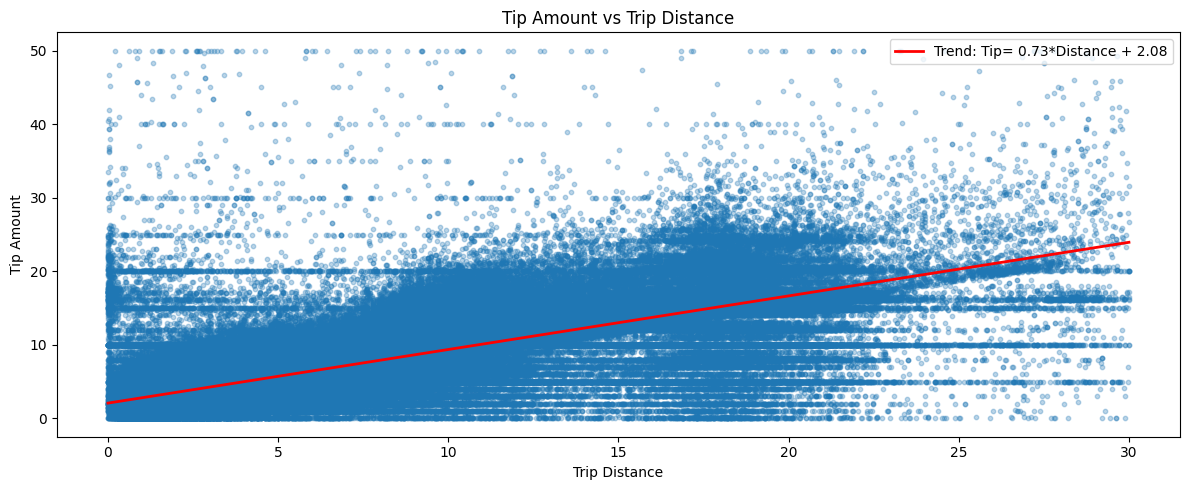

Correlation: 0.7778631806107122


In [40]:
# Show relationship between tip and trip distance
# Show relationship between fare and trip duration

correlation_tip_dist = df_tips['trip_distance'].corr(df_tips['tip_amount'])
plt.figure(figsize=(12, 5))

filter_data = df_tips[(df_tips['trip_distance'] > 0) &
                         (df_tips['trip_distance'] <= 30) &
                         (df_tips['tip_amount'] <= 50)]

plt.scatter(filter_data['trip_distance'], filter_data['tip_amount'], alpha=0.3, s=10)
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')

z=np.polyfit(filter_data['trip_distance'], filter_data['tip_amount'],1)
p=np.poly1d(z)
x_axis=np.linspace(0, 30, 100)
plt.plot(x_axis, p(x_axis),"r-", linewidth=2, label=f'Trend: Tip= {z[0]:.2f}*Distance + {z[1]:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation: {correlation_tip_dist}")




**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

             payment_type  Num Trips  percentage  Total revenue  Avg rate
payment_type                                                             
1             Credit Card    1578580        81.6    47156297.62     29.87
2                    Cash     333377        17.2     8403904.14     25.21
4                 Dispute      14356         0.7      368976.29     25.70
3               No charge       8884         0.5      191384.67     21.54


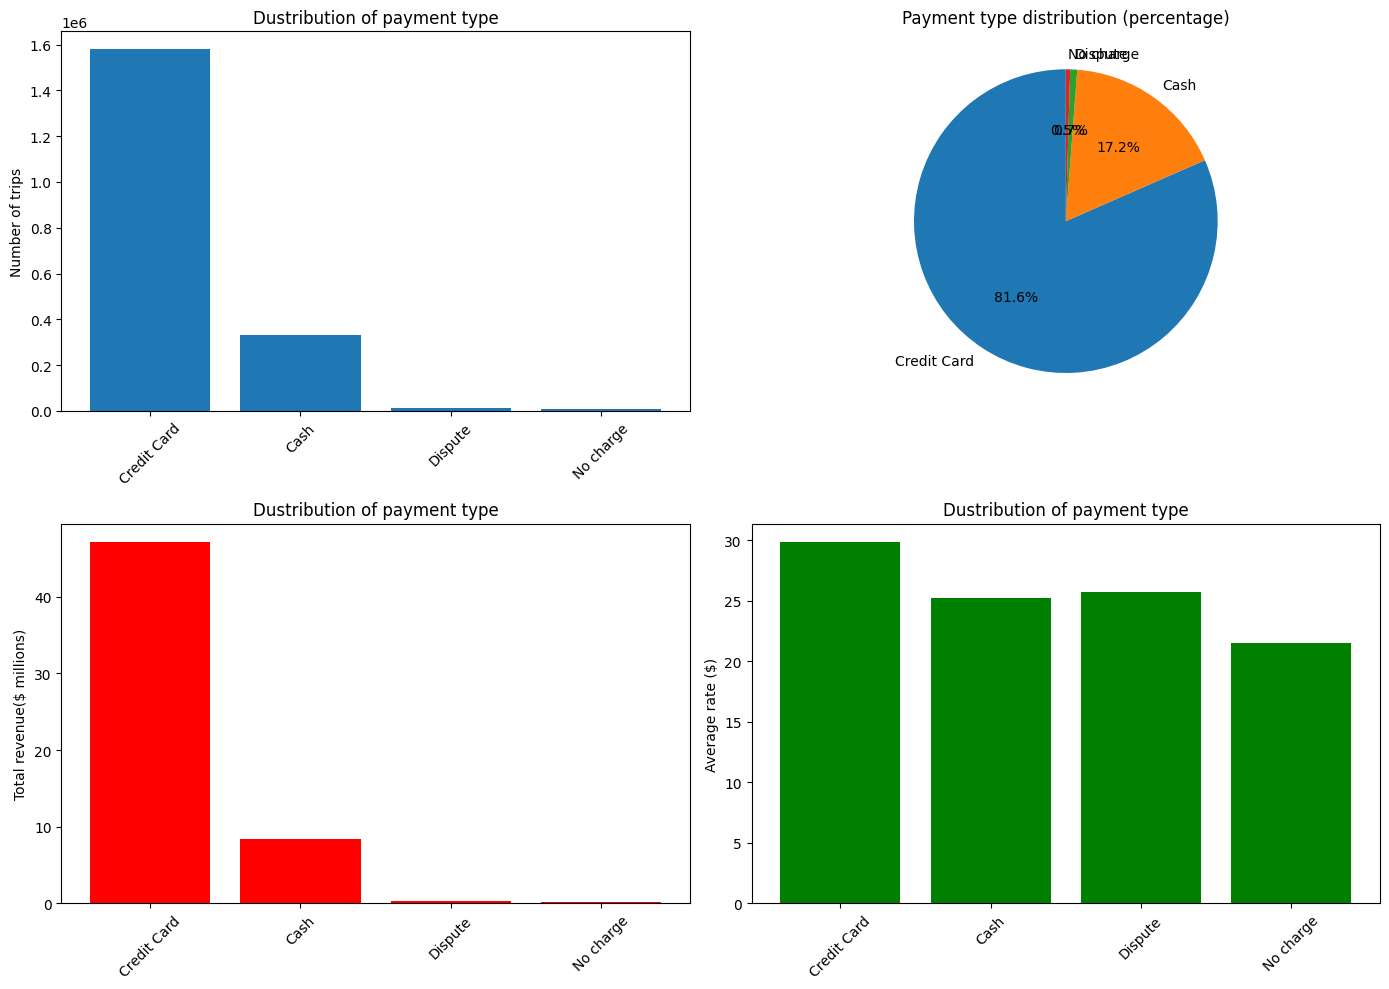

In [41]:
# Analyse the distribution of different payment types (payment_type).
payment_types = {
    0: 'Unknown',
    1: 'Credit Card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
}

payment_dist = (df.groupby('payment_type')['total_amount']
                 .agg(['count', 'sum', 'mean'])
                 .rename(columns={'count':'Num Trips', 'sum': 'Total revenue', 'mean': 'Avg rate'})
                 .round(2))

payment_dist['payment_type'] = payment_dist.index.map(lambda x: payment_types.get(int(x), 'Unknown'))
payment_dist['percentage'] = (payment_dist['Num Trips'] / payment_dist['Num Trips'].sum() * 100).round(1)
payment_dist = payment_dist.sort_values('Num Trips', ascending=False)
print(payment_dist[['payment_type', 'Num Trips', 'percentage', 'Total revenue', 'Avg rate']].to_string())

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
labels = payment_dist['payment_type']

ax[0,0].bar(labels, payment_dist['Num Trips'])
ax[0,0].set(title='Dustribution of payment type', ylabel='Number of trips')
ax[0,0].tick_params(axis='x', rotation=45)

ax[0,1].pie(payment_dist['Num Trips'], labels=labels, autopct='%1.1f%%', startangle=90)
ax[0,1].set(title='Payment type distribution (percentage)')

ax[1,0].bar(labels, payment_dist['Total revenue']/1e6, color='red')
ax[1,0].set(title='Dustribution of payment type', ylabel='Total revenue($ millions)')
ax[1,0].tick_params(axis='x', rotation=45)

ax[1,1].bar(labels, payment_dist['Avg rate'], color='green')
ax[1,1].set(title='Dustribution of payment type', ylabel='Average rate ($)')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones_path = "/content/drive/MyDrive/content/Assignments/EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp"
zones = gpd.read_file(zones_path)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

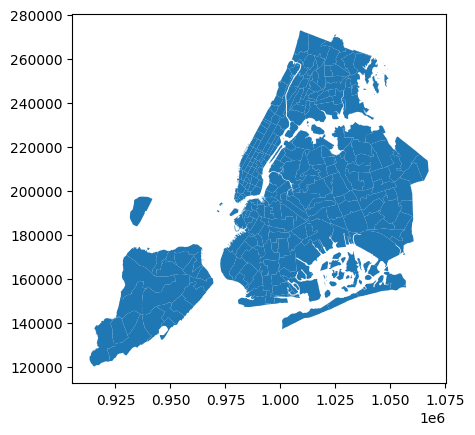

In [44]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID

zones_PU = zones[['LocationID', 'zone', 'borough', 'geometry']].copy()
zones_PU.rename(columns={'LocationID': 'PULocationID', 'zone': 'pu_zone', 'borough': 'pu_borough'}, inplace=True)

df_zones = df.merge(zones_PU, on='PULocationID', how='left')
print(df_zones[['PULocationID', 'pu_zone', 'pu_borough', 'total_amount']].head(10))




   PULocationID                       pu_zone pu_borough  total_amount
0           114       Greenwich Village South  Manhattan         26.20
1           144           Little Italy/NoLiTa  Manhattan         45.72
2           230     Times Sq/Theatre District  Manhattan         19.68
3           132                   JFK Airport     Queens         99.23
4           186  Penn Station/Madison Sq West  Manhattan         14.60
5           237         Upper East Side South  Manhattan         16.12
6            48                  Clinton East  Manhattan         12.90
7            48                  Clinton East  Manhattan         30.45
8           141               Lenox Hill West  Manhattan         15.48
9            79                  East Village  Manhattan         28.92


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [46]:
# Group data by location and calculate the number of trips
data_by_location=df_zones.groupby('PULocationID').agg({
    'total_amount': ['count'],
    'pu_zone': 'first',
    'pu_borough': 'first'
}).round(2)

data_by_location.columns = ['Num_trips', 'Zone', 'Borough']
data_by_location = data_by_location.reset_index()
data_by_location = data_by_location.sort_values('Num_trips', ascending=False)
print(data_by_location)


     PULocationID  Num_trips                   Zone        Borough
128           132     103651            JFK Airport         Queens
232           237      91879  Upper East Side South      Manhattan
157           161      90422         Midtown Center      Manhattan
231           236      80887  Upper East Side North      Manhattan
158           162      69777           Midtown East      Manhattan
..            ...        ...                    ...            ...
106           109          1            Great Kills  Staten Island
107           111          1    Green-Wood Cemetery       Brooklyn
58             59          1           Crotona Park          Bronx
171           176          1                Oakwood  Staten Island
194           199          1          Rikers Island          Bronx

[260 rows x 4 columns]


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [47]:
# Merge trip counts back to the zones GeoDataFrame
zone_with_trips = zones.merge(data_by_location[['PULocationID', 'Num_trips']],
                              left_on='LocationID', right_on='PULocationID', how='left')
zone_with_trips['Num_trips']= zone_with_trips['Num_trips'].fillna(0).astype(int)

print(zone_with_trips.nlargest(10, 'Num_trips')[['zone', 'LocationID', 'Num_trips']])


                             zone  LocationID  Num_trips
131                   JFK Airport         132     103651
236         Upper East Side South         237      91879
160                Midtown Center         161      90422
235         Upper East Side North         236      80887
161                  Midtown East         162      69777
137             LaGuardia Airport         138      68326
185  Penn Station/Madison Sq West         186      67681
229     Times Sq/Theatre District         230      65001
141           Lincoln Square East         142      63538
169                   Murray Hill         170      57774


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

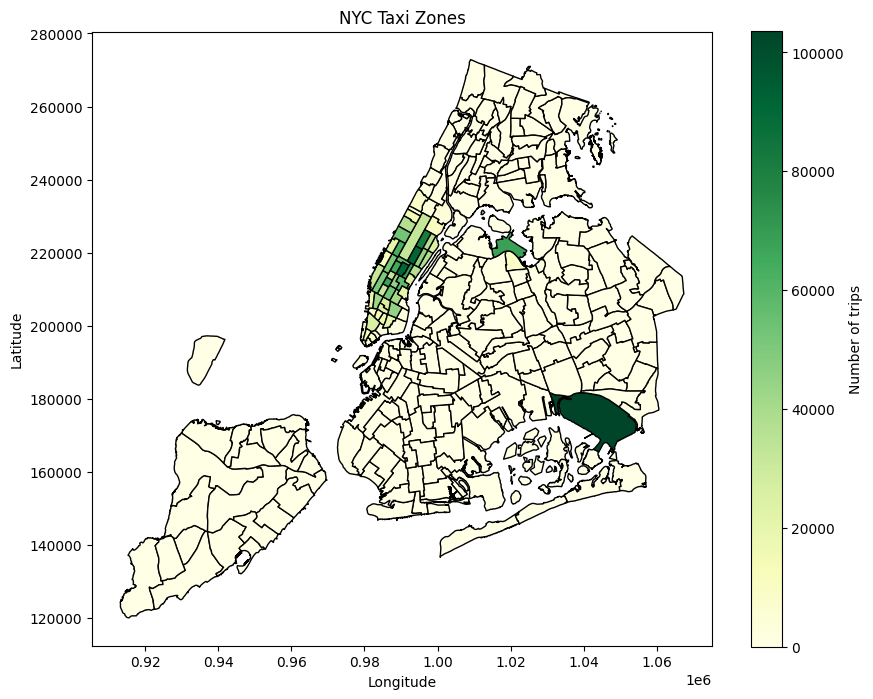

In [48]:
from matplotlib import legend
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (10, 8))

# Plot the map and display it
zone_with_trips.plot(column='Num_trips', ax=ax, cmap='YlGn', edgecolor='black', legend=True, legend_kwds={'label': "Number of trips", 'orientation': "vertical"})
plt.title('NYC Taxi Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [49]:
# can you try displaying the zones DF sorted by the number of trips?
zones_sorted = zone_with_trips[["LocationID", "zone", "borough", "Num_trips"]].sort_values(by="Num_trips", ascending=False).reset_index(drop=True)
print("Zones sorted by number of trips (Total zones: " + str(len(zones_sorted)) + ")")
print(zones_sorted.to_string())

Zones sorted by number of trips (Total zones: 263)
     LocationID                                           zone        borough  Num_trips
0           132                                    JFK Airport         Queens     103651
1           237                          Upper East Side South      Manhattan      91879
2           161                                 Midtown Center      Manhattan      90422
3           236                          Upper East Side North      Manhattan      80887
4           162                                   Midtown East      Manhattan      69777
5           138                              LaGuardia Airport         Queens      68326
6           186                   Penn Station/Madison Sq West      Manhattan      67681
7           230                      Times Sq/Theatre District      Manhattan      65001
8           142                            Lincoln Square East      Manhattan      63538
9           170                                    Murray H

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [50]:
# Find routes which have the slowest speeds at different times of the day
df_route_speed = df_nonzero[(df_nonzero['trip_distance'] > 0) & (df_nonzero['trip_duration'] > 0)].copy()
df_route_speed['speed'] = (df_route_speed['trip_distance'] / df_route_speed['trip_duration'] *60).clip(0,100)
df_route_speed['pickup_hour'] = df_route_speed['tpep_pickup_datetime'].dt.hour
df_route_speed['route'] = df_route_speed['PULocationID'].astype(str) + " - " + df_route_speed['DOLocationID'].astype(str)

slowest_route = df_route_speed.groupby(['pickup_hour', 'route']).agg({
    'speed':['mean', 'count'],
    'trip_distance': 'mean'
}).round(2)
slowest_route.columns = ['Avg speed', 'Num trips', 'Avg distance']
slowest_route = slowest_route.reset_index()
slowest_route = slowest_route[slowest_route['Num trips'] >= 10]
print('\nslowest route: ')
print(slowest_route)

slowest_10 = slowest_route.nsmallest(10, 'Avg speed')[['route', 'pickup_hour', 'Avg speed', 'Num trips', 'Avg distance']]
print(print('\nslowest 10: '))
print(slowest_10)

speed_by_hour = df_route_speed.groupby('pickup_hour')['speed'].mean().round(2)

print('\nspeed by hour:')
print(speed_by_hour)


slowest route: 
        pickup_hour      route  Avg speed  Num trips  Avg distance
9                 0  100 - 100       6.86         11          0.74
11                0  100 - 107       9.72         17          1.60
14                0  100 - 114      12.49         11          2.28
19                0  100 - 137       8.55         13          1.27
20                0  100 - 140      11.94         11          2.84
...             ...        ...        ...        ...           ...
127128           23    90 - 68       9.88         56          0.80
127129           23     90 - 7      13.09         12          6.14
127133           23    90 - 79       9.12         62          1.56
127135           23    90 - 87      11.48         11          3.01
127138           23    90 - 90       8.83         17          0.50

[36743 rows x 5 columns]

slowest 10: 
None
           route  pickup_hour  Avg speed  Num trips  Avg distance
73714  144 - 144           15       3.15         10          0.26
60

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

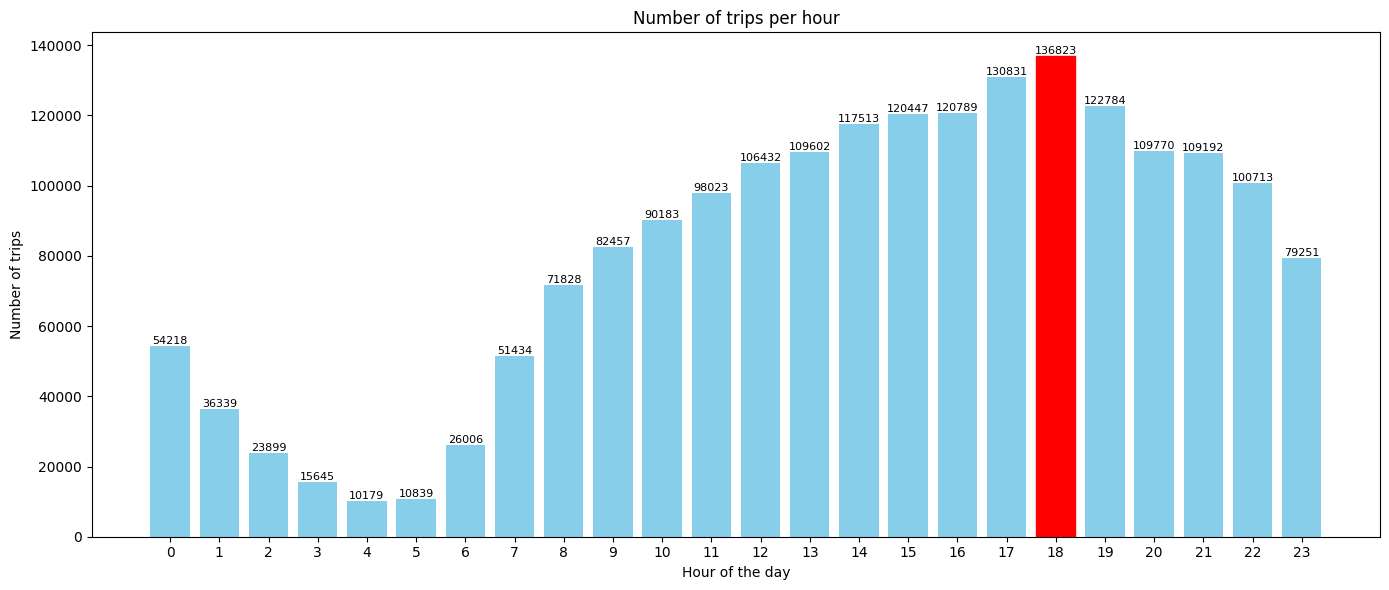

In [51]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trip = df.groupby('hour').size().reset_index(name='trips')
busy_hour = hourly_trip.loc[hourly_trip['trips'].idxmax()]

plt.figure(figsize=(14,6))
bars = plt.bar(hourly_trip['hour'], hourly_trip['trips'], color='skyblue')
bars[int(busy_hour['hour'])].set_color('red')
plt.xlabel('Hour of the day')
plt.ylabel('Number of trips')
plt.title('Number of trips per hour')
plt.xticks(range(0,24))

for i, (hour, trips) in enumerate(zip(hourly_trip['hour'], hourly_trip['trips'])):
    plt.text(i, trips, str(int(trips)), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [52]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

top_5_hours = hourly_trip.nlargest(5, 'trips')[['hour', 'trips']].copy()
top_5_hours.columns = ['Hour', 'Sample Trip']
top_5_hours['Scaled Trips'] = (top_5_hours['Sample Trip'] / sample_fraction).astype(int)

print(top_5_hours.to_string(index=False))
print("\n 5 busiest hours")
for idx, row in top_5_hours.iterrows():
    print(f" Hour {int(row['Hour']):02d}:00 :  {row['Scaled Trips']} trips")



 Hour  Sample Trip  Scaled Trips
   18       136823       2736460
   17       130831       2616620
   19       122784       2455680
   16       120789       2415780
   15       120447       2408940

 5 busiest hours
 Hour 18:00 :  2736460 trips
 Hour 17:00 :  2616620 trips
 Hour 19:00 :  2455680 trips
 Hour 16:00 :  2415780 trips
 Hour 15:00 :  2408940 trips


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

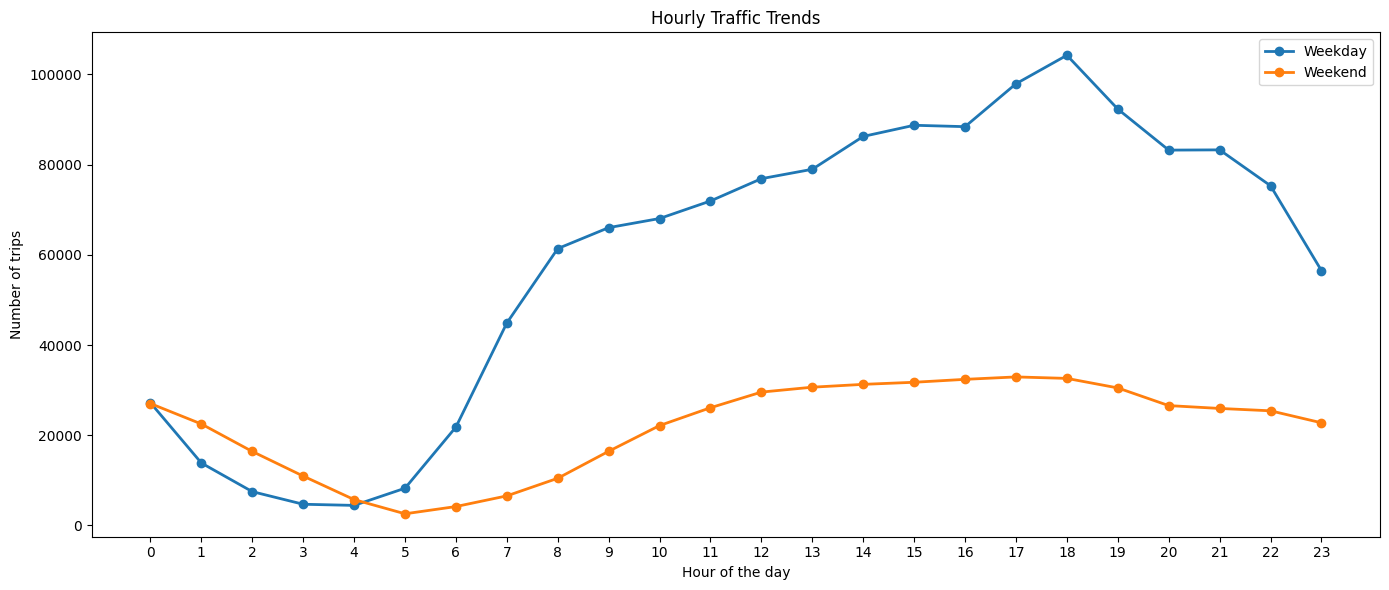

In [53]:
# Compare traffic trends for the week days and weekends
df['is_weekend'] = df['pickup_week'].isin([5,6])

hourly_day_type = df.groupby(['hour', 'is_weekend']).size().unstack(fill_value=0)
hourly_day_type.columns = ['Weekday', 'Weekend']

plt.figure(figsize=(14, 6))
plt.plot(hourly_day_type.index, hourly_day_type['Weekday'], marker='o', label='Weekday', linewidth=2)
plt.plot(hourly_day_type.index, hourly_day_type['Weekend'], marker='o', label='Weekend', linewidth=2)
plt.xlabel('Hour of the day')
plt.ylabel('Number of trips')
plt.title('Hourly Traffic Trends')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

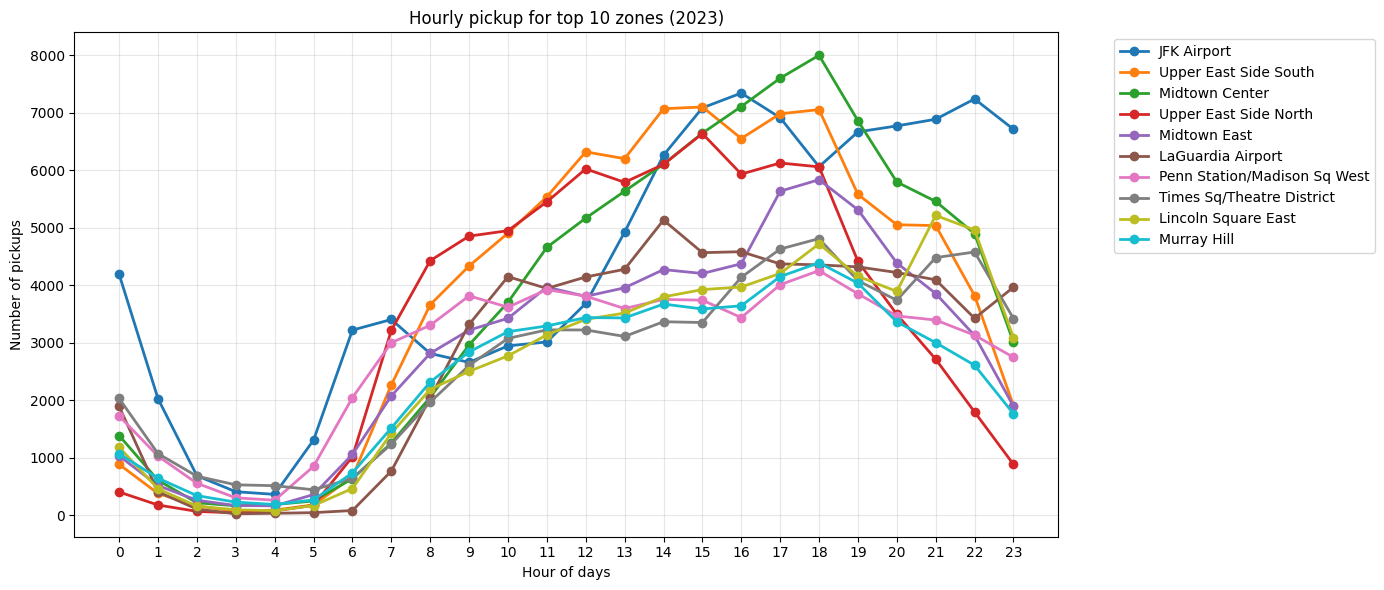


Top 10 zones
pu_zone
JFK Airport                     103651
Upper East Side South            91879
Midtown Center                   90422
Upper East Side North            80887
Midtown East                     69777
LaGuardia Airport                68326
Penn Station/Madison Sq West     67681
Times Sq/Theatre District        65001
Lincoln Square East              63538
Murray Hill                      57774
Name: count, dtype: int64


In [54]:
# Find top 10 pickup and dropoff zones
hourly_pickup_zone = df_zones.groupby(['hour', 'pu_zone']).size().unstack(fill_value=0)

top_10_pickup = df_zones['pu_zone'].value_counts().head(10).index.tolist()

plt.figure(figsize=(14, 6))
for zone in top_10_pickup:
  if zone in hourly_pickup_zone.columns:
    plt.plot(hourly_pickup_zone.index, hourly_pickup_zone[zone], marker='o', label=zone, linewidth=2)

plt.xlabel('Hour of days')
plt.ylabel('Number of pickups')
plt.title('Hourly pickup for top 10 zones (2023)')
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 zones")
print(df_zones['pu_zone'].value_counts().head(10))


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [55]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pu_counts=df_zones.groupby('pu_zone').size().reset_index(name='pickups')
pu_counts.columns = ['Zone', 'Pickups']

zones_do = zones[['LocationID', 'zone']].copy()
zones_do.rename(columns={'LocationID': 'DOLocationID', 'zone': 'do_zone'}, inplace=True)
df_with_zones = df_zones.merge(zones_do, on='DOLocationID', how='left')

do_counts = df_with_zones.groupby('do_zone').size().reset_index(name='dropoffs')
do_counts.columns = ['Zone', 'Dropoffs']

zone_ratio = pd.merge(pu_counts, do_counts, on='Zone', how='outer').fillna(0)

zone_ratio['Ratio'] = zone_ratio.apply(lambda row: row['Pickups'] / row['Dropoffs'] if row['Dropoffs'] > 0 else float('nan'), axis=1)

zone_valid_ratio = zone_ratio.dropna(subset=['Ratio'])
zone_ratio = zone_valid_ratio.sort_values('Ratio', ascending=False).reset_index(drop=True)

print("Top 10 zones: ")
print(zone_ratio.head(10))
print("\nBottom 10 zones: ")
print(zone_ratio.tail(10))


Top 10 zones: 
                           Zone   Pickups  Dropoffs     Ratio
0                 East Elmhurst    8901.0    1092.0  8.151099
1                   JFK Airport  103651.0   22684.0  4.569344
2             LaGuardia Airport   68326.0   23627.0  2.891861
3                   Jamaica Bay       2.0       1.0  2.000000
4  Penn Station/Madison Sq West   67681.0   42557.0  1.590361
5       Greenwich Village South   25689.0   18381.0  1.397584
6                  Central Park   32546.0   23688.0  1.373945
7                  West Village   43267.0   32305.0  1.339328
8                  Midtown East   69777.0   54790.0  1.273535
9              Garment District   32478.0   26794.0  1.212137

Bottom 10 zones: 
                       Zone  Pickups  Dropoffs     Ratio
247                 Bayside     18.0     334.0  0.053892
248              Douglaston     13.0     250.0  0.052000
249         Windsor Terrace     41.0     795.0  0.051572
250                 Oakwood      1.0      20.0  0.050000

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

                              Total Pickups  Night Pickups  Night Pct
pu_zone                                                              
East Village                          45309        16089.0      35.51
JFK Airport                          103651        14403.0      13.90
West Village                          43267        13250.0      30.62
Clinton East                          51441        10337.0      20.09
Lower East Side                       19625        10117.0      51.55
Greenwich Village South               25689         9422.0      36.68
Times Sq/Theatre District             65001         8259.0      12.71
Penn Station/Madison Sq West          67681         6635.0       9.80
LaGuardia Airport                     68326         6444.0       9.43
Midtown South                         45154         6370.0      14.11
East Chelsea                          50948         6176.0      12.12
Union Sq                              52423         5952.0      11.35
Gramercy            

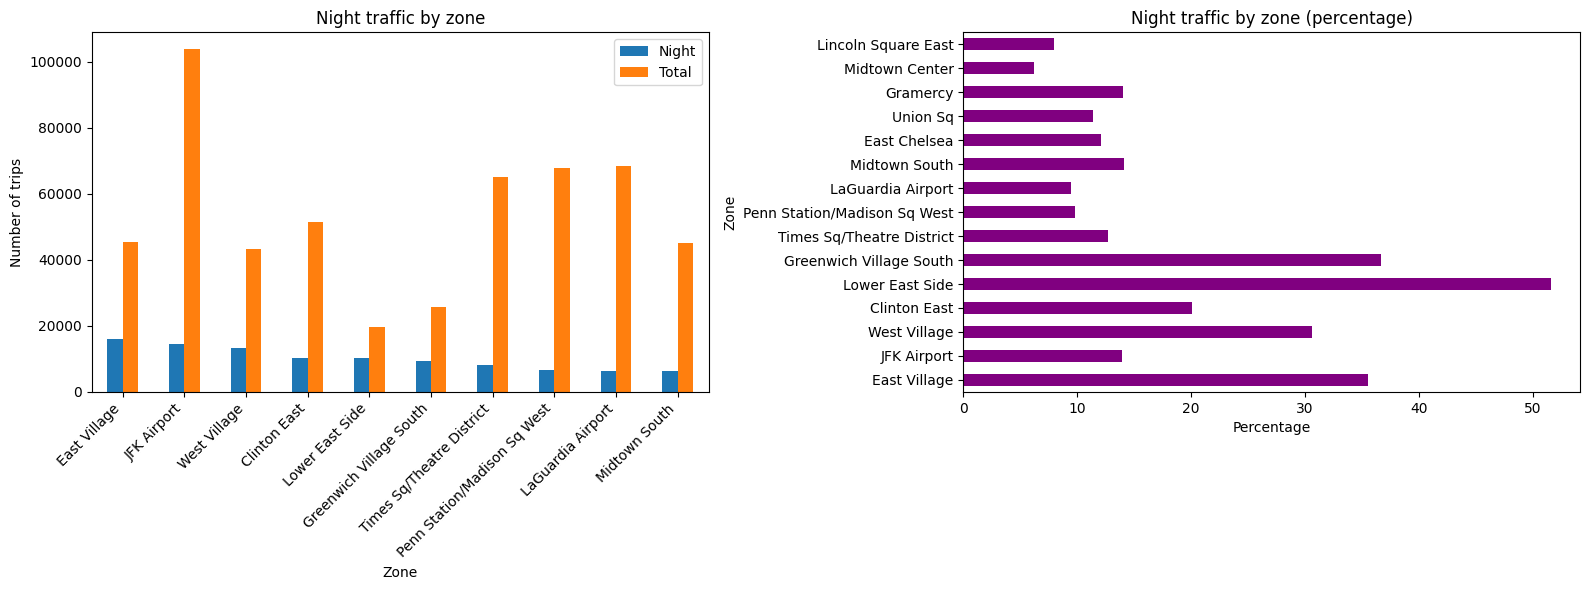

In [56]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
hours = [23, 0, 1, 2, 3, 4]
df_night = df_zones[df_zones['hour'].isin(hours)]

night_pickups = df_night['pu_zone'].value_counts()

total_pickups = df_zones['pu_zone'].value_counts()

night_compare = pd.DataFrame({
    'Total Pickups': total_pickups,
    'Night Pickups': night_pickups,
    'Night Pct': (night_pickups / total_pickups *100).round(2)
    }).fillna(0).sort_values('Night Pickups', ascending=False)

print(night_compare.head(15))

print("Zone with high night traffic")
night_compare_high_pct = night_compare[night_compare['Night Pct'] >= 35].sort_values('Night Pct', ascending=False)
print(night_compare_high_pct.head(10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

night_compare.head(10)[['Night Pickups', 'Total Pickups']].plot(kind='bar', ax=ax1)
ax1.set_xlabel('Zone')
ax1.set_ylabel('Number of trips')
ax1.set_title('Night traffic by zone')
ax1.legend(['Night', 'Total'])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

night_compare.head(15)['Night Pct'].plot(kind='barh', ax=ax2, color='purple')
ax2.set_xlabel('Percentage')
ax2.set_ylabel('Zone')
ax2.set_title('Night traffic by zone (percentage)')

plt.tight_layout()
plt.show()



Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Revenue: Night Vs Day
Night: $6407874.63
Day: $49712688.09
Total: $56120562.72
Night: 11.42%
Day: 88.58%
Night trip count: 219531
Day trip count: 1715666
Night Avg fare: $29.19
Day Avg fare: $28.98


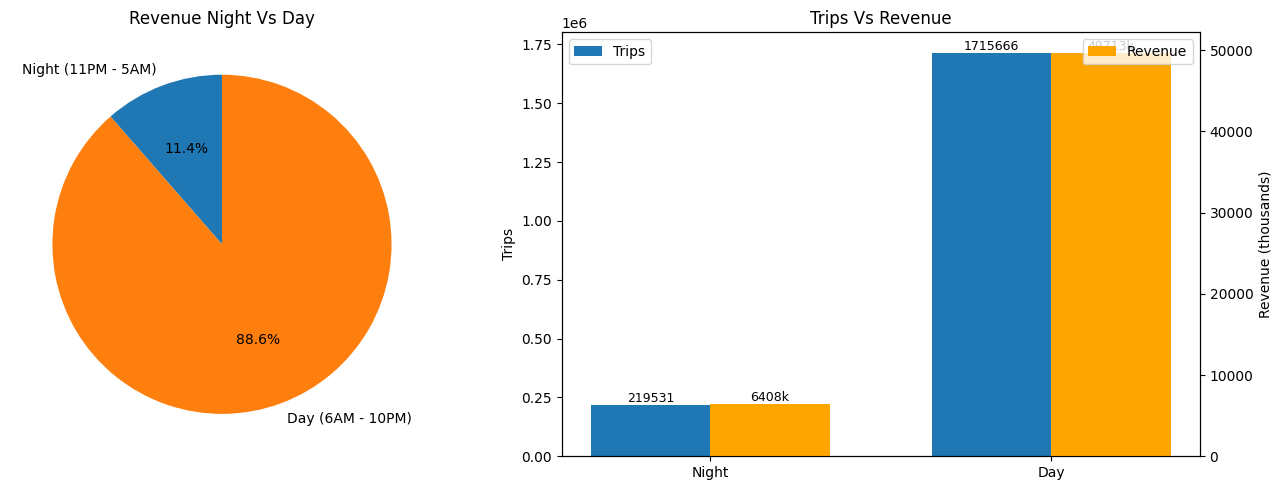

In [57]:
# Filter for night hours (11 PM to 5 AM)
hours = [23, 0, 1, 2, 3, 4]
df_night = df[df['hour'].isin(hours)]
df_day =df[~df['hour'].isin(hours)]

night_reven = df_night['total_amount'].sum()
day_reven = df_day['total_amount'].sum()
total_reven = df['total_amount'].sum()

night_per = (night_reven / total_reven) *100
day_per = (day_reven / total_reven) *100

print("Revenue: Night Vs Day")
print(f"Night: ${night_reven:.2f}")
print(f"Day: ${day_reven:.2f}")
print(f"Total: ${total_reven:.2f}")
print(f"Night: {night_per:.2f}%")
print(f"Day: {day_per:.2f}%")
print(f"Night trip count: {len(df_night)}")
print(f"Day trip count: {len(df_day)}")
print(f"Night Avg fare: ${df_night['total_amount'].mean():.2f}")
print(f"Day Avg fare: ${df_day['total_amount'].mean():.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie([night_reven, day_reven],
        labels=['Night (11PM - 5AM)', 'Day (6AM - 10PM)'],
        autopct = '%1.1f%%',
        startangle=90)
ax1.set_title("Revenue Night Vs Day")

categories = ['Night', 'Day']
trips = [len(df_night), len(df_day)]
revenues = [night_reven/1000, day_reven/1000]

x=np.arange(len(categories))
width=0.35

ax2_twin = ax2.twinx()
bars1 = ax2.bar(x-width/2, trips, width=width, label='Trips')
bars2 = ax2_twin.bar(x+width/2, revenues, width=width, color='orange', label='Revenue')
ax2.set_ylabel('Trips')
ax2_twin.set_ylabel('Revenue (thousands)')
ax2.set_title('Trips Vs Revenue')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)

for bar in bars1:
  height = bar.get_height()
  ax2.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
  height = bar.get_height()
  ax2_twin.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}k', ha='center', va='bottom', fontsize=9)

ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

                fare_amount               fare_per_mile                 \
                       mean median    std          mean median     std   
passenger_count                                                          
1.0                   19.06   13.5  17.23         10.89   7.17  122.06   
2.0                   22.06   14.2  20.33         13.28   7.03  172.71   
3.0                   21.81   14.2  20.83         11.14   7.11  115.08   
4.0                   23.29   14.9  22.34         18.67   7.08  267.04   
5.0                   19.10   13.5  17.39          8.64   7.08   65.20   
6.0                   19.39   13.5  17.38          8.62   7.18   39.05   

                fare_per_mile_per_passenger        trip_distance  
                                       mean median          mean  
passenger_count                                                   
1.0                                   16.69  11.46          3.35  
2.0                                    9.58   5.50          4.11 

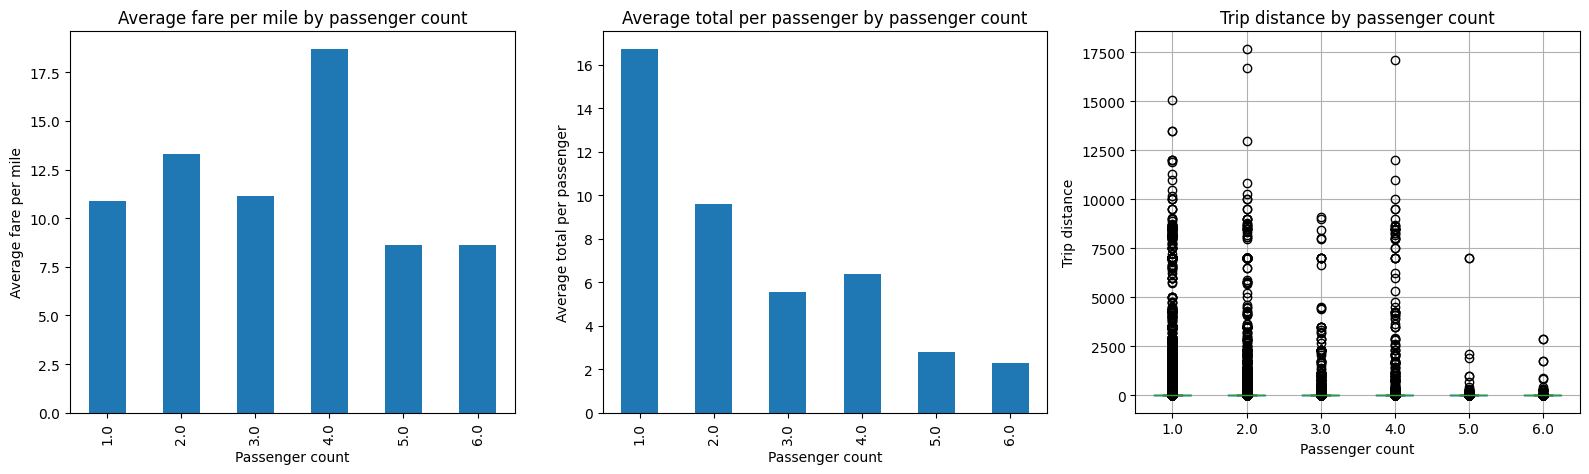

In [58]:
# Analyse the fare per mile per passenger for different passenger counts

df_analysis = df[(df['trip_distance'] > 0) &
                 (df['total_amount'] > 0) &
                 (df['passenger_count'] > 0)].copy()
df_analysis['fare_per_mile'] = df_analysis['fare_amount'] / df_analysis['trip_distance']
df_analysis['fare_per_mile_per_passenger'] = df_analysis['total_amount'] / (df_analysis['trip_distance'] * df_analysis['passenger_count'])

fare_by_passengers = df_analysis.groupby('passenger_count').agg({
    'fare_amount' : ['mean', 'median', 'std'],
    'fare_per_mile' : ['mean', 'median', 'std'],
    'fare_per_mile_per_passenger' : ['mean', 'median'],
    'trip_distance' : 'mean'
}).round(2)

print(fare_by_passengers)
print("\n")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

avg_fare = df_analysis.groupby('passenger_count')['fare_per_mile'].mean()
avg_fare.plot(kind='bar', ax=ax[0])
ax[0].set_xlabel('Passenger count')
ax[0].set_ylabel('Average fare per mile')
ax[0].set_title('Average fare per mile by passenger count')

avg_total_per_passenger = df_analysis.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
avg_total_per_passenger.plot(kind='bar', ax=ax[1])
ax[1].set_xlabel('Passenger count')
ax[1].set_ylabel('Average total per passenger')
ax[1].set_title('Average total per passenger by passenger count')

df_analysis.boxplot(column='fare_per_mile', by='passenger_count', ax=ax[2])
ax[2].set_xlabel('Passenger count')
ax[2].set_ylabel('Trip distance')
ax[2].set_title('Trip distance by passenger count')

plt.suptitle('')
plt.tight_layout()
plt.show()



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

                          fare_amount               trip_distance  \
                                count   mean median          mean   
distance_tier vendor_name                                           
0-2 miles     Green Cab        273375  10.08    9.3          1.16   
              Yellow Cab       786703  10.37   10.0          1.16   
2-5 miles     Green Cab        123705  19.07   18.4          3.05   
              Yellow Cab       395791  19.27   18.4          3.00   
5+ miles      Green Cab         76238  48.82   43.6         11.52   
              Yellow Cab       256372  51.06   45.7         11.86   

                          total_amount passenger_count  
                                  mean            mean  
distance_tier vendor_name                               
0-2 miles     Green Cab          16.89            1.29  
              Yellow Cab         17.29            1.40  
2-5 miles     Green Cab          27.23            1.32  
              Yellow Cab         27.

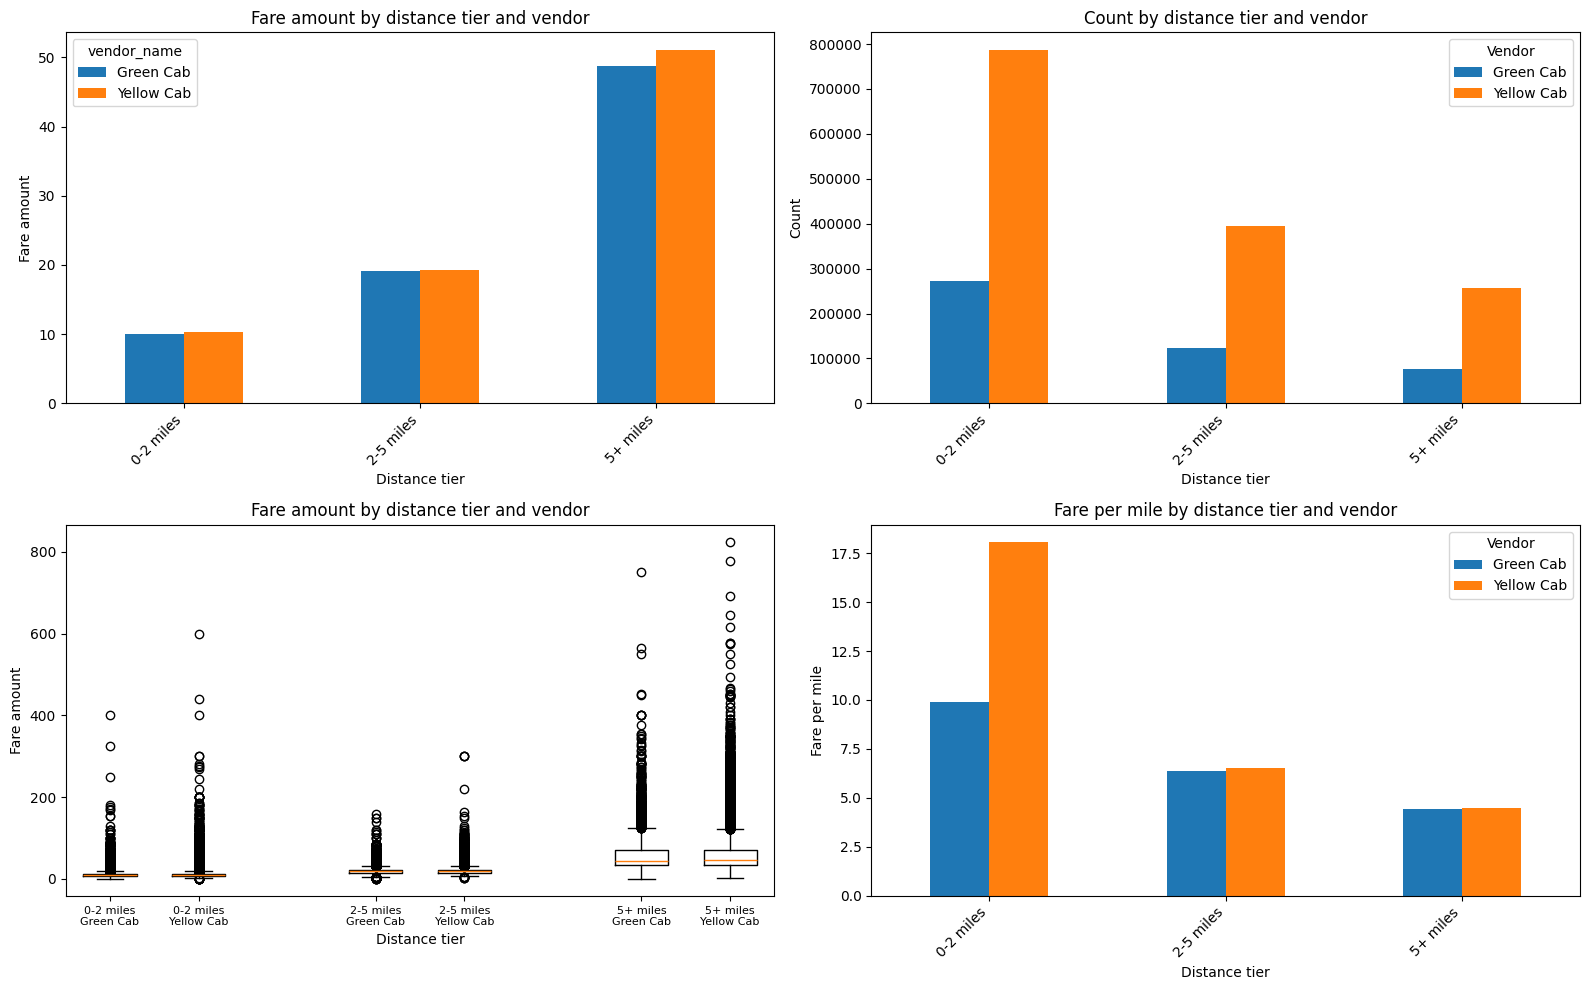

In [59]:
# Compare the average fare per mile for different days and for different times of the day
df_analysis = df[(df['trip_distance'] > 0) &
                 (df['fare_amount'] > 0)].copy()

def distance_tier(distance):
  if distance <=2:
    return '0-2 miles'
  elif distance <=5:
    return '2-5 miles'
  else:
    return '5+ miles'

df_analysis['distance_tier'] = df_analysis['trip_distance'].apply(distance_tier)
vendor_names = {1: 'Green Cab', 2: 'Yellow Cab'}
df_analysis['vendor_name'] = df_analysis['VendorID'].map(vendor_names)

tier_vendor_analysis = df_analysis.groupby(['distance_tier', 'vendor_name']).agg({
    'fare_amount': ['count', 'mean', 'median'],
    'trip_distance': 'mean',
    'total_amount': 'mean',
    'passenger_count': 'mean'
}).round(2)

print(tier_vendor_analysis)
print("\n")

tier_vendor_fare = df_analysis.pivot_table(
    values='fare_amount',
    index='distance_tier',
    columns='vendor_name',
    aggfunc='mean'
)
teir_vendor_fare = tier_vendor_fare.reindex(['0-2 miles', '2-5 miles', '5+ miles'])

tier_vendor_count = df_analysis.pivot_table(
    values='fare_amount',
    index='distance_tier',
    columns='vendor_name',
    aggfunc='count'
)
teir_vendor_count = tier_vendor_count.reindex(['0-2 miles', '2-5 miles', '5+ miles'])
print("\nVendor Fare: ")
print(tier_vendor_fare.round(2))
print("\nVendor Count: ")
print(teir_vendor_count.astype(int))

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

tier_vendor_fare.plot(kind='bar', ax=ax[0,0])
ax[0,0].set_xlabel('Distance tier')
ax[0,0].set_ylabel('Fare amount')
ax[0,0].set_title('Fare amount by distance tier and vendor')
plt.setp(ax[0,0].xaxis.get_majorticklabels(), rotation=45, ha='right')

tier_vendor_count.plot(kind='bar', ax=ax[0,1])
ax[0,1].set_xlabel('Distance tier')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Count by distance tier and vendor')
ax[0,1].legend(title='Vendor')
plt.setp(ax[0,1].xaxis.get_majorticklabels(), rotation=45, ha='right')

tier_list = ['0-2 miles', '2-5 miles', '5+ miles']
positions = []
labels = []
data_plot=[]

for i, tier in enumerate(tier_list):
  for j, vendor in enumerate(['Green Cab', 'Yellow Cab']):
    data=df_analysis[(df_analysis['distance_tier'] == tier) & (df_analysis['vendor_name'] == vendor)]['fare_amount']
    data_plot.append(data)
    positions.append(i*3 + j)
    labels.append(f"{tier}\n{vendor}")

ax[1,0].boxplot(data_plot, positions=positions, widths=0.6)
ax[1,0].set_title('Fare amount by distance tier and vendor')
ax[1,0].set_xlabel('Distance tier')
ax[1,0].set_ylabel('Fare amount')
ax[1,0].set_xticklabels(labels, fontsize=8)

stats_data=[]
for tier in tier_list:
  for vendor in ['Green Cab', 'Yellow Cab']:
    subset=df_analysis[(df_analysis['distance_tier'] == tier) & (df_analysis['vendor_name'] == vendor)]
    stats_data.append({
        'Tier':tier,
        "Vendor":vendor,
        "Avg fare": subset['fare_amount'].mean(),
        "Fare per mile":(subset['fare_amount'] / subset['trip_distance']).mean()
    })

stats_df = pd.DataFrame(stats_data)
pivot_stats = stats_df.pivot_table(index='Tier', columns='Vendor', values='Fare per mile')
pivot_stats = pivot_stats.reindex(tier_list)

pivot_stats.plot(kind='bar', ax=ax[1,1])
ax[1,1].set_xlabel('Distance tier')
ax[1,1].set_ylabel('Fare per mile')
ax[1,1].set_title('Fare per mile by distance tier and vendor')
ax[1,1].legend(title='Vendor')
plt.setp(ax[1,1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

vendor_name  Vendor 1 (CMT)  Vendor 2 (VTS)
hour                                       
0                      6.86           11.62
1                      6.88           13.62
2                      6.70           11.95
3                      7.23           13.36
4                      6.95           19.41
5                      7.10           18.93
6                      6.77           11.96
7                      7.25           10.87
8                      7.95           11.46
9                      8.39           12.05
10                     8.47           11.79
11                     8.69           11.74
12                     8.83           13.18
13                     8.80           13.13
14                     8.62           13.40
15                     8.70           14.88
16                     8.64           14.89
17                     8.64           13.72
18                     8.52           12.19
19                     7.90           11.52
20                     7.49     

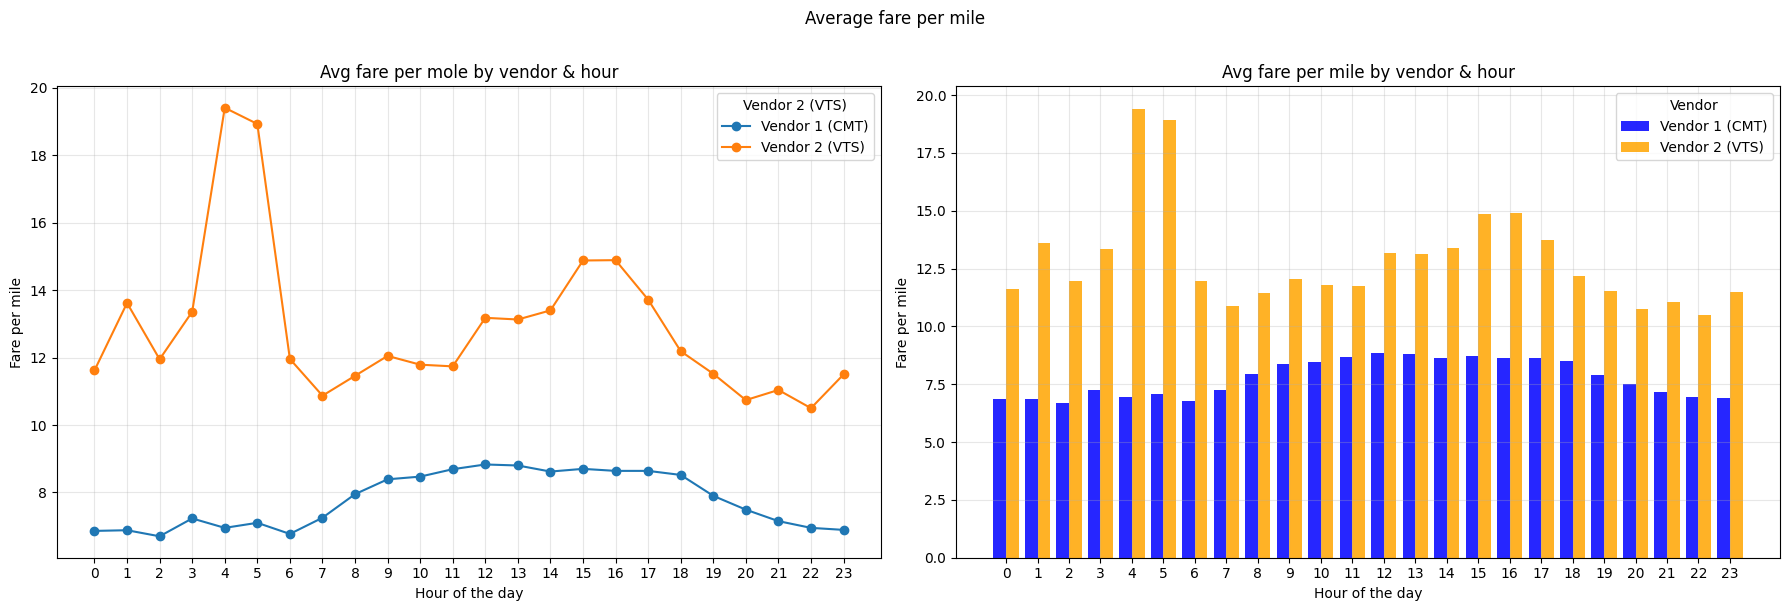

In [60]:
# Compare fare per mile for different vendors
df_vendor = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()
df_vendor['fare_per_mile'] = df_vendor['fare_amount'] / df_vendor['trip_distance']
df_vendor['hour'] = pd.to_datetime(df_vendor['tpep_pickup_datetime']).dt.hour

vendor_map = {1: 'Vendor 1 (CMT)', 2: 'Vendor 2 (VTS)'}
df_vendor['vendor_name'] = df_vendor['VendorID'].map(vendor_map).fillna('Unknown')

vendor_hour_fare = df_vendor.groupby(['vendor_name', 'hour'])['fare_per_mile'].mean().round(2)
vendor_hour_fare = vendor_hour_fare.unstack(level=0)

print(vendor_hour_fare.to_string())
print("\n")

for vendor in vendor_hour_fare.columns:
  col=vendor_hour_fare[vendor].dropna()
  peak_hr=col.idxmax()
  low_hr=col.idxmin()
  print(f"Vendor: {vendor}")
  print(f"Overall avg fare: ${col.mean():.2f}")
  print(f"Peak hour: {peak_hr}:00")
  print(f"Low hour: {low_hr}:00")


fig, ax = plt.subplots(1, 2, figsize=(18, 6))

vendor_colors = {'Vendor 1 (CMT)': 'blue', 'Vendor 2 (VTS)': 'orange'}
for vendor in vendor_hour_fare.columns:
  ax[0].plot(
      vendor_hour_fare.index,
      vendor_hour_fare[vendor],
      marker='o',
      label=vendor
    )
ax[0].set_title('Avg fare per mole by vendor & hour')
ax[0].set_ylabel('Fare per mile')
ax[0].set_xlabel('Hour of the day')
ax[0].set_xticks(range(0, 24))
ax[0].legend(title = vendor)
ax[0].grid(True, alpha=0.3)

hour = vendor_hour_fare.index
x = np.arange(len(hour))
num_vendors = len(vendor_hour_fare.columns)
bar_width = 0.8 / num_vendors

for offset, (vendor, color) in enumerate(vendor_colors.items()):
  if vendor in vendor_hour_fare.columns:
    positions = x + offset * bar_width - (num_vendors-1) * bar_width/2
    ax[1].bar(positions, vendor_hour_fare[vendor], width=bar_width, label=vendor, color=color, alpha=0.85)

ax[1].set_title('Avg fare per mile by vendor & hour')
ax[1].set_ylabel('Fare per mile')
ax[1].set_xlabel('Hour of the day')
ax[1].set_xticks(list(x))
ax[1].set_xticklabels([str(h) for h in hour])
ax[1].legend(title='Vendor')
ax[1].grid(True, alpha=0.3)

plt.suptitle('Average fare per mile', y=1.01)
plt.tight_layout()
plt.show()




**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


vendor_name    Vendor 1 (CMT)  Vendor 2 (VTS)
distance_tier                                
0-2 miles                9.88           18.04
2-5 miles                6.38            6.55
5+ miles                 4.43            4.50


vendor_name    Vendor 1 (CMT)  Vendor 2 (VTS)
distance_tier                                
0-2 miles              273375          786703
2-5 miles              123705          395791
5+ miles                76238          256372
Tier: 0-2 miles
Vendor 1 (CMT): $9.88 (273375 trips)
Vendor 2 (VTS): $18.04 (786703 trips)


Tier: 2-5 miles
Vendor 1 (CMT): $6.38 (123705 trips)
Vendor 2 (VTS): $6.55 (395791 trips)


Tier: 5+ miles
Vendor 1 (CMT): $4.43 (76238 trips)
Vendor 2 (VTS): $4.50 (256372 trips)




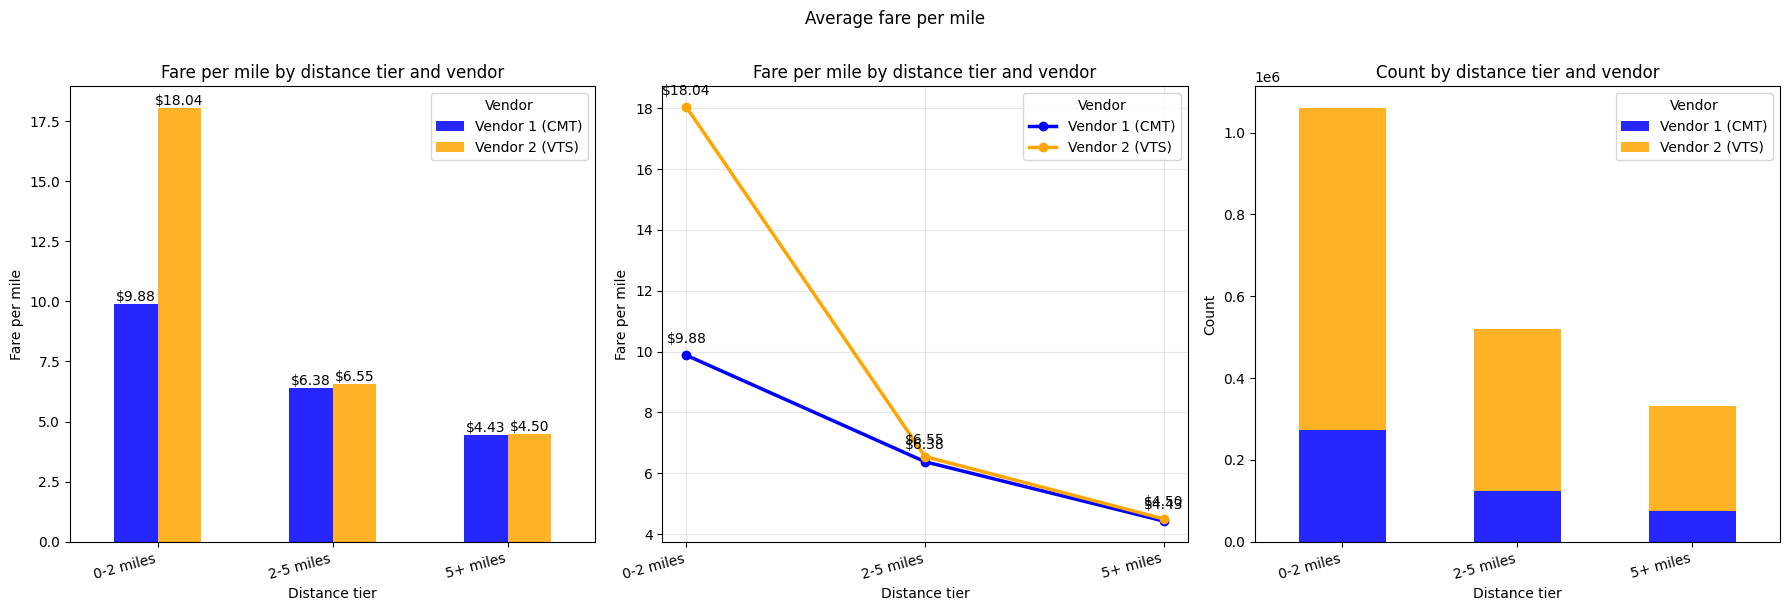

In [61]:
# Defining distance tiers
df_tier = df[(df['trip_distance'] > 0) & (df['fare_amount'] >0)].copy()
df_tier['fare_per_mile'] = df_tier['fare_amount'] / df_tier['trip_distance']

vendor_map = {1: 'Vendor 1 (CMT)', 2: 'Vendor 2 (VTS)'}
df_tier['vendor_name'] = df_tier['VendorID'].map(vendor_map).fillna('Unknown')

def distance_tier(distance):
  if distance <=2:
    return '0-2 miles'
  elif distance <=5:
    return '2-5 miles'
  else:
    return '5+ miles'

df_tier['distance_tier'] = df_tier['trip_distance'].apply(distance_tier)
tier_order = ['0-2 miles', '2-5 miles', '5+ miles']

pivot_avg = df_tier.pivot_table(
    values='fare_per_mile',
    index='distance_tier',
    columns='vendor_name',
    aggfunc='mean'
).round(2).reindex(tier_order)

pivot_count = df_tier.pivot_table(
    values='fare_per_mile',
    index='distance_tier',
    columns='vendor_name',
    aggfunc='count'
).reindex(tier_order).fillna(0).astype(int)

print(pivot_avg.to_string())
print("\n")
print(pivot_count.to_string())

for tier in tier_order:
  print(f"Tier: {tier}")
  for vendor in pivot_avg.columns:
    val = pivot_avg.loc[tier, vendor]
    cnt = int(pivot_count.loc[tier, vendor])
    print(f"{vendor}: ${val:.2f} ({cnt} trips)")
  print("\n")

vendor_colors = {'Vendor 1 (CMT)': 'blue', 'Vendor 2 (VTS)': 'orange'}
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

pivot_avg.plot(kind='bar', ax=ax[0],
               color=[vendor_colors.get(c, 'grey') for c in pivot_avg.columns] ,
               alpha=0.85)
ax[0].set_xlabel('Distance tier')
ax[0].set_ylabel('Fare per mile')
ax[0].set_title('Fare per mile by distance tier and vendor')
ax[0].set_xticklabels(tier_order, rotation=15, ha='right')
ax[0].legend(title='Vendor')
for container in ax[0].containers:
  ax[0].bar_label(container, fmt='$%.2f')


for vendor in pivot_avg.columns:
  ax[1].plot(range(len(tier_order)), pivot_avg[vendor].values,marker='o',
             label=vendor, linewidth=2.5, color=vendor_colors.get(vendor, 'grey'))
  for j, val in enumerate(pivot_avg[vendor].values):
    ax[1].annotate(f"${val:.2f}", (j, val), textcoords="offset points", xytext=(0, 9),
                   ha='center')

ax[1].set_title('Fare per mile by distance tier and vendor')
ax[1].set_ylabel('Fare per mile')
ax[1].set_xlabel('Distance tier')
ax[1].set_xticks(range(len(tier_order)))
ax[1].set_xticklabels(tier_order, rotation=15, ha='right')
ax[1].legend(title='Vendor')
ax[1].grid(True, alpha=0.3)


pivot_count.plot(kind='bar', stacked=True, ax=ax[2],
                 color=[vendor_colors.get(c, 'grey') for c in pivot_avg.columns] ,
                 alpha=0.85)
ax[2].set_xlabel('Distance tier')
ax[2].set_ylabel('Count')
ax[2].set_title('Count by distance tier and vendor')
ax[2].set_xticklabels(tier_order, rotation=15, ha='right')
ax[2].legend(title='Vendor')

plt.suptitle('Average fare per mile', y=1.01)
plt.tight_layout()
plt.show()




##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

               Avg Tip%  Median Tip%   Trips
distance_tier                               
0-2 miles         15.65        16.67  833138
2-5 miles         15.17        16.67  421229
5+ miles          15.12        16.65  249409


                Avg Tip%  Median Tip%      Trips
pax_group                                       
1 passenger        15.42        16.67  1161188.0
2 passengers       15.45        16.67   226860.0
3-4 passengers       NaN          NaN        NaN
5+ passengers      15.48        16.67   115728.0


hour
0     15.20
1     15.19
2     15.24
3     15.23
4     15.60
5     15.36
6     15.21
7     15.24
8     15.30
9     15.54
10    15.67
11    15.72
12    15.69
13    15.70
14    15.67
15    15.56
16    15.38
17    15.28
18    15.27
19    15.23
20    15.38
21    15.42
22    15.34
23    15.24


day_week
Monday       15.46
Tuesday      15.43
Wednesday    15.45
Thursday     15.42
Friday       15.40
Saturday     15.41
Sunday       15.44


Avg distance  - Low tip: 3.56 mi | Hig

/tmp/ipykernel_6808/759037508.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(day_order, rotation=30, ha='right')


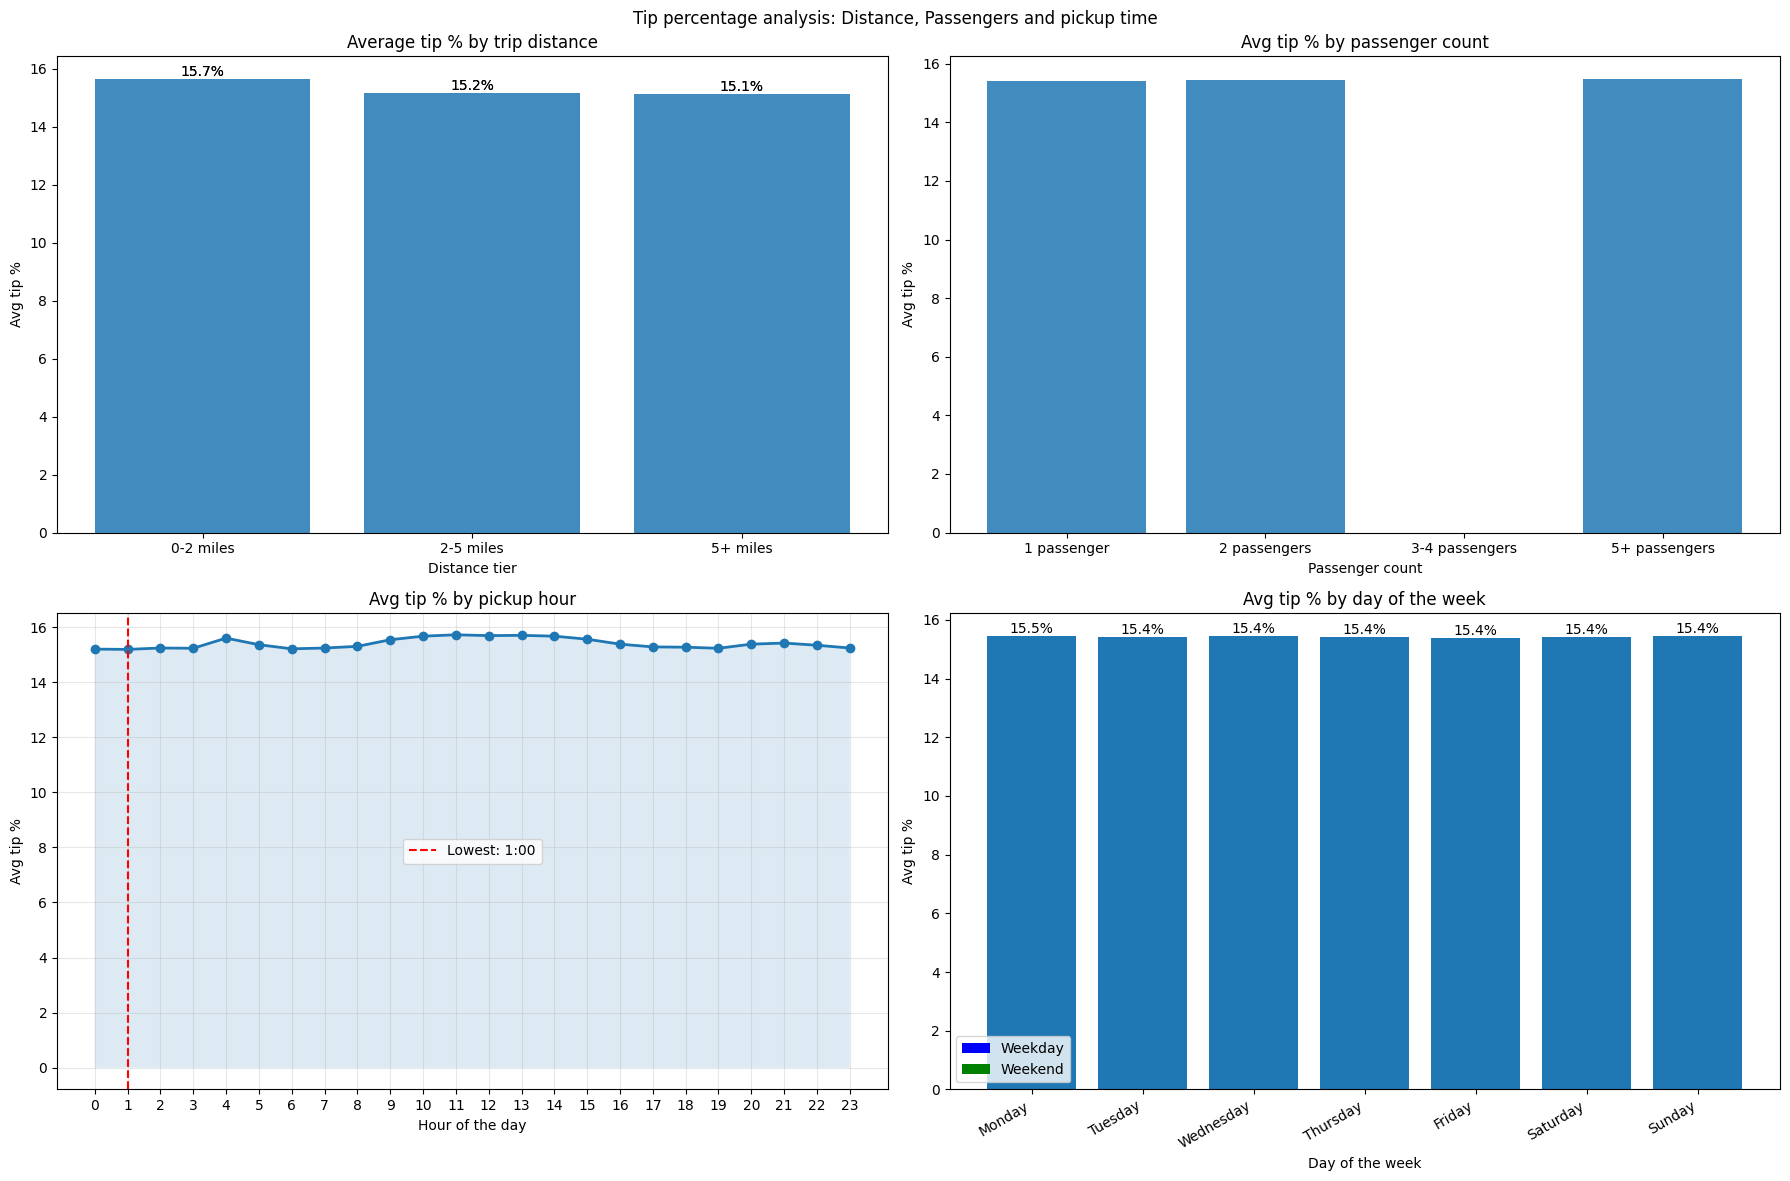

In [62]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_tip = df[(df['payment_type'] == 1) &
            (df['fare_amount'] > 0) &
            (df['total_amount'] > 0) &
            (df['tip_amount'] > 0)].copy()

df_tip['tip_percentage'] = (df_tip['tip_amount'] / df_tip['total_amount']) * 100
df_tip['hour'] = pd.to_datetime(df_tip['tpep_pickup_datetime']).dt.hour
df_tip['day_week'] = pd.to_datetime(df_tip['tpep_pickup_datetime']).dt.day_name()

def dist_tier(d):
  if d<=2: return '0-2 miles'
  elif d<=5: return '2-5 miles'
  else: return '5+ miles'

df_tip['distance_tier'] = df_tip['trip_distance'].apply(dist_tier)
tier_order = ['0-2 miles', '2-5 miles', '5+ miles']

df_tip['pax_group'] = df_tip['passenger_count'].apply(
    lambda x: '1 passenger' if x==1
    else ('2 passengers' if x==2
    else ('3-4 passengers' if x in [3-4]
    else '5+ passengers'))
)
pax_order = ['1 passenger', '2 passengers', '3-4 passengers', '5+ passengers']

tip_by_dist = df_tip.groupby('distance_tier')['tip_percentage'].agg(['mean', 'median', 'count']).round(2)
tip_by_dist = tip_by_dist.reindex(tier_order)
print(tip_by_dist.rename(columns={'mean': 'Avg Tip%', 'median': 'Median Tip%', 'count': 'Trips'}).to_string())
print("\n")

tip_by_pax = df_tip.groupby('pax_group')['tip_percentage'].agg(['mean', 'median', 'count']).round(2)
tip_by_pax = tip_by_pax.reindex(pax_order)
print(tip_by_pax.rename(columns={'mean': 'Avg Tip%', 'median': 'Median Tip%', 'count': 'Trips'}).to_string())
print("\n")

tip_by_hour = df_tip.groupby('hour')['tip_percentage'].mean().round(2)
print(tip_by_hour.to_string())
print("\n")

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tip_by_day = df_tip.groupby('day_week')['tip_percentage'].mean().round(2).reindex(day_order)
print(tip_by_day.to_string())
print("\n")

low_tip_threshold = df_tip['tip_percentage'].quantile(0.25)
df_low = df_tip[df_tip['tip_percentage'] < low_tip_threshold]
df_high = df_tip[df_tip['tip_percentage'] >= low_tip_threshold]
print(f'Avg distance  - Low tip: {df_low["trip_distance"].mean():.2f} mi | High tip: {df_high["trip_distance"].mean():.2f} mi')
print(f'Avg passengers- Low tip: {df_low["passenger_count"].mean():.2f}   | High tip: {df_high["passenger_count"].mean():.2f}')
print(f'Avg hour      - Low tip: {df_low["hour"].mean():.1f}h       | High tip: {df_high["hour"].mean():.1f}h')

fig, ax = plt.subplots(2, 2, figsize=(18,12))

bars1 = ax[0,0].bar(tip_by_dist.index, tip_by_dist['mean'],
                    alpha=0.85)
ax[0,0].set_xlabel('Distance tier')
ax[0,0].set_ylabel('Avg tip %')
ax[0,0].set_title('Average tip % by trip distance')
ax[0,0].bar_label(bars1, fmt='%.1f%%')

valid_pax = [p for p in pax_order if p in tip_by_pax.index]
bars2 = ax[0,1].bar(valid_pax, tip_by_pax.loc[valid_pax, 'mean'],
                    alpha=0.85)
ax[0,1].set_title('Avg tip % by passenger count')
ax[0,1].set_xlabel('Passenger count')
ax[0,1].set_ylabel('Avg tip %')
ax[0,0].bar_label(bars1, fmt='%.1f%%')

ax[1,0].plot(tip_by_hour.index, tip_by_hour.values,
             marker='o', linewidth=2)
ax[1,0].fill_between(tip_by_hour.index, tip_by_hour.values, alpha=0.15)
ax[1,0].set_title('Avg tip % by pickup hour')
ax[1,0].set_xlabel('Hour of the day')
ax[1,0].set_ylabel('Avg tip %')
ax[1,0].grid(True, alpha=0.3)
ax[1,0].set_xticks(range(0, 24))
ax[1,0].set_xticklabels([str(h) for h in range(0, 24)])

low_hr = tip_by_hour.idxmin()
ax[1,0].axvline(x=low_hr, color='red', linestyle='--', label=f'Lowest: {low_hr}:00')
ax[1,0].legend()

bars4 = ax[1,1].bar(day_order, tip_by_day.values)
ax[1,1].set_title('Avg tip % by day of the week')
ax[1,1].set_xlabel('Day of the week')
ax[1,1].set_ylabel('Avg tip %')
ax[1,1].bar_label(bars4, fmt='%.1f%%')
ax[1,1].set_xticklabels(day_order, rotation=30, ha='right')

from matplotlib.patches import Patch
ax[1,1].legend(handles=[
    Patch(facecolor='blue', label='Weekday'),
    Patch(facecolor='green', label='Weekend')])

plt.suptitle('Tip percentage analysis: Distance, Passengers and pickup time')
plt.tight_layout()
plt.show()



[link text](https://)Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [63]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.


 day_name
Monday       1.37
Tuesday      1.34
Wednesday    1.34
Thursday     1.35
Friday       1.41
Saturday     1.49
Sunday       1.47

Busiest day: Saturday → avg 1.49 passengers
Quietest day: Tuesday → avg 1.34 passengers


/tmp/ipykernel_6808/3092545315.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[1,1].boxplot(box_data, labels=day_order,


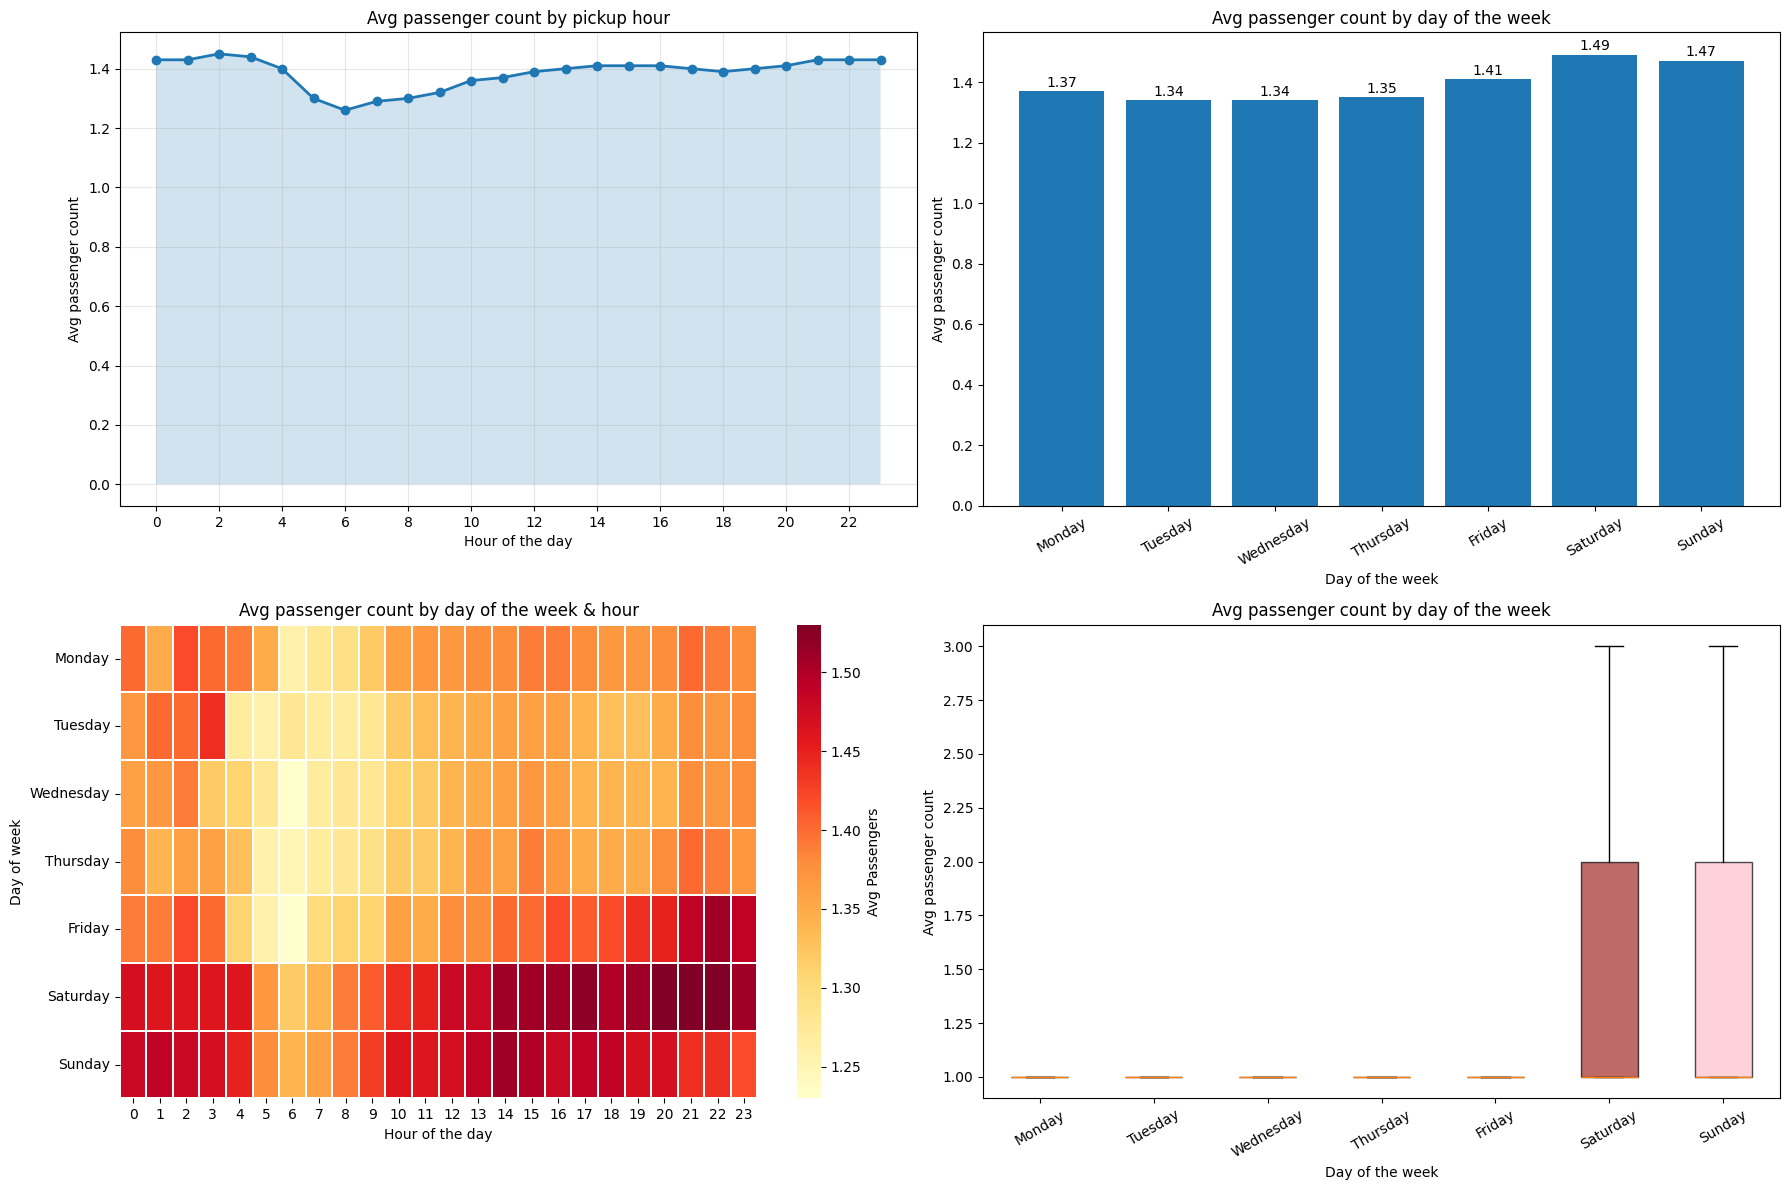

• Hourly range: 1.26 – 1.45 passengers
• Late-night hours (0–4 AM) tend to have higher avg passengers (likely group rides/nightlife)
• Weekends (1.49, 1.47 avg) vs Weekdays (1.36 avg)
• Passenger count shows relatively modest variation overall, suggesting most trips are solo regardless of time/day


In [64]:
# See how passenger count varies across hours and days
day_names = {0: 'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df_pax = df.copy()

df_pax['day_week'] = pd.to_datetime(df_pax['tpep_pickup_datetime']).dt.dayofweek
df_pax['day_name'] = df_pax['day_week'].map(day_names)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pax_by_hour = df_pax.groupby('hour')['passenger_count'].mean().round(2)
pax_by_day = df_pax.groupby('day_name')['passenger_count'].mean().reindex(day_order).round(2)

heatmap_data = df_pax.groupby(['day_name', 'hour'])['passenger_count'].mean().unstack(level=1).reindex(day_order).round(2)
print("\n", pax_by_day.to_string())
print(f"\nBusiest day: {pax_by_day.idxmax()} → avg {pax_by_day.max():.2f} passengers")
print(f"Quietest day: {pax_by_day.idxmin()} → avg {pax_by_day.min():.2f} passengers")

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

ax[0,0].plot(pax_by_hour.index, pax_by_hour.values,
             marker='o', linewidth=2)
ax[0,0].fill_between(pax_by_hour.index, pax_by_hour.values, alpha=0.2)
ax[0,0].set_title('Avg passenger count by pickup hour')
ax[0,0].set_xlabel('Hour of the day')
ax[0,0].set_ylabel('Avg passenger count')
ax[0,0].set_xticks(range(0, 24, 2))
ax[0,0].grid(True, alpha=0.3)

colors_day = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink']
bars = ax[0,1].bar(day_order, pax_by_day.values, linewidth=1)
ax[0,1].set_title('Avg passenger count by day of the week')
ax[0,1].set_xlabel('Day of the week')
ax[0,1].set_ylabel('Avg passenger count')
ax[0,1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, pax_by_day.values):
  ax[0,1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
               f'{val:.2f}', ha='center', va='bottom')

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax[1,0],
            cbar_kws={'label' : 'Avg Passengers'}, linewidth=0.3)
ax[1,0].set_title('Avg passenger count by day of the week & hour')
ax[1,0].set_xlabel('Hour of the day')
ax[1,0].set_ylabel('Day of week')


box_data = [df_pax[df_pax['day_name'] == d]['passenger_count'].values for d in day_order]
bp = ax[1,1].boxplot(box_data, labels=day_order,
                     patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_day):
  patch.set_facecolor(color); patch.set_alpha(0.7)
ax[1,1].set_title('Avg passenger count by day of the week')
ax[1,1].set_xlabel('Day of the week')
ax[1,1].set_ylabel('Avg passenger count')
ax[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"• Hourly range: {pax_by_hour.min():.2f} – {pax_by_hour.max():.2f} passengers")
print(f"• Late-night hours (0–4 AM) tend to have higher avg passengers "
      f"(likely group rides/nightlife)")
print(f"• Weekends ({pax_by_day['Saturday']:.2f}, {pax_by_day['Sunday']:.2f} avg) "
      f"vs Weekdays ({pax_by_day[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean():.2f} avg)")
print("• Passenger count shows relatively modest variation overall, "
      "suggesting most trips are solo regardless of time/day")



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones


Total zones analysed (≥50 trips): 183

Top 10 Zones — Highest Average Passenger Count:
                              Avg_passengers  Median_passengers  Std_dev  Trip_count
pu_zone                                                                             
Red Hook                                1.85                2.0     1.07         203
Newark Airport                          1.84                1.0     1.10         250
Battery Park                            1.83                1.0     1.16         825
Maspeth                                 1.57                1.0     1.08         128
World Trade Center                      1.55                1.0     1.01        9965
Flushing Meadows-Corona Park            1.54                1.0     0.94         386
Chinatown                               1.54                1.0     1.00        2509
DUMBO/Vinegar Hill                      1.53                1.0     0.93         501
Central Park                            1.51                1.

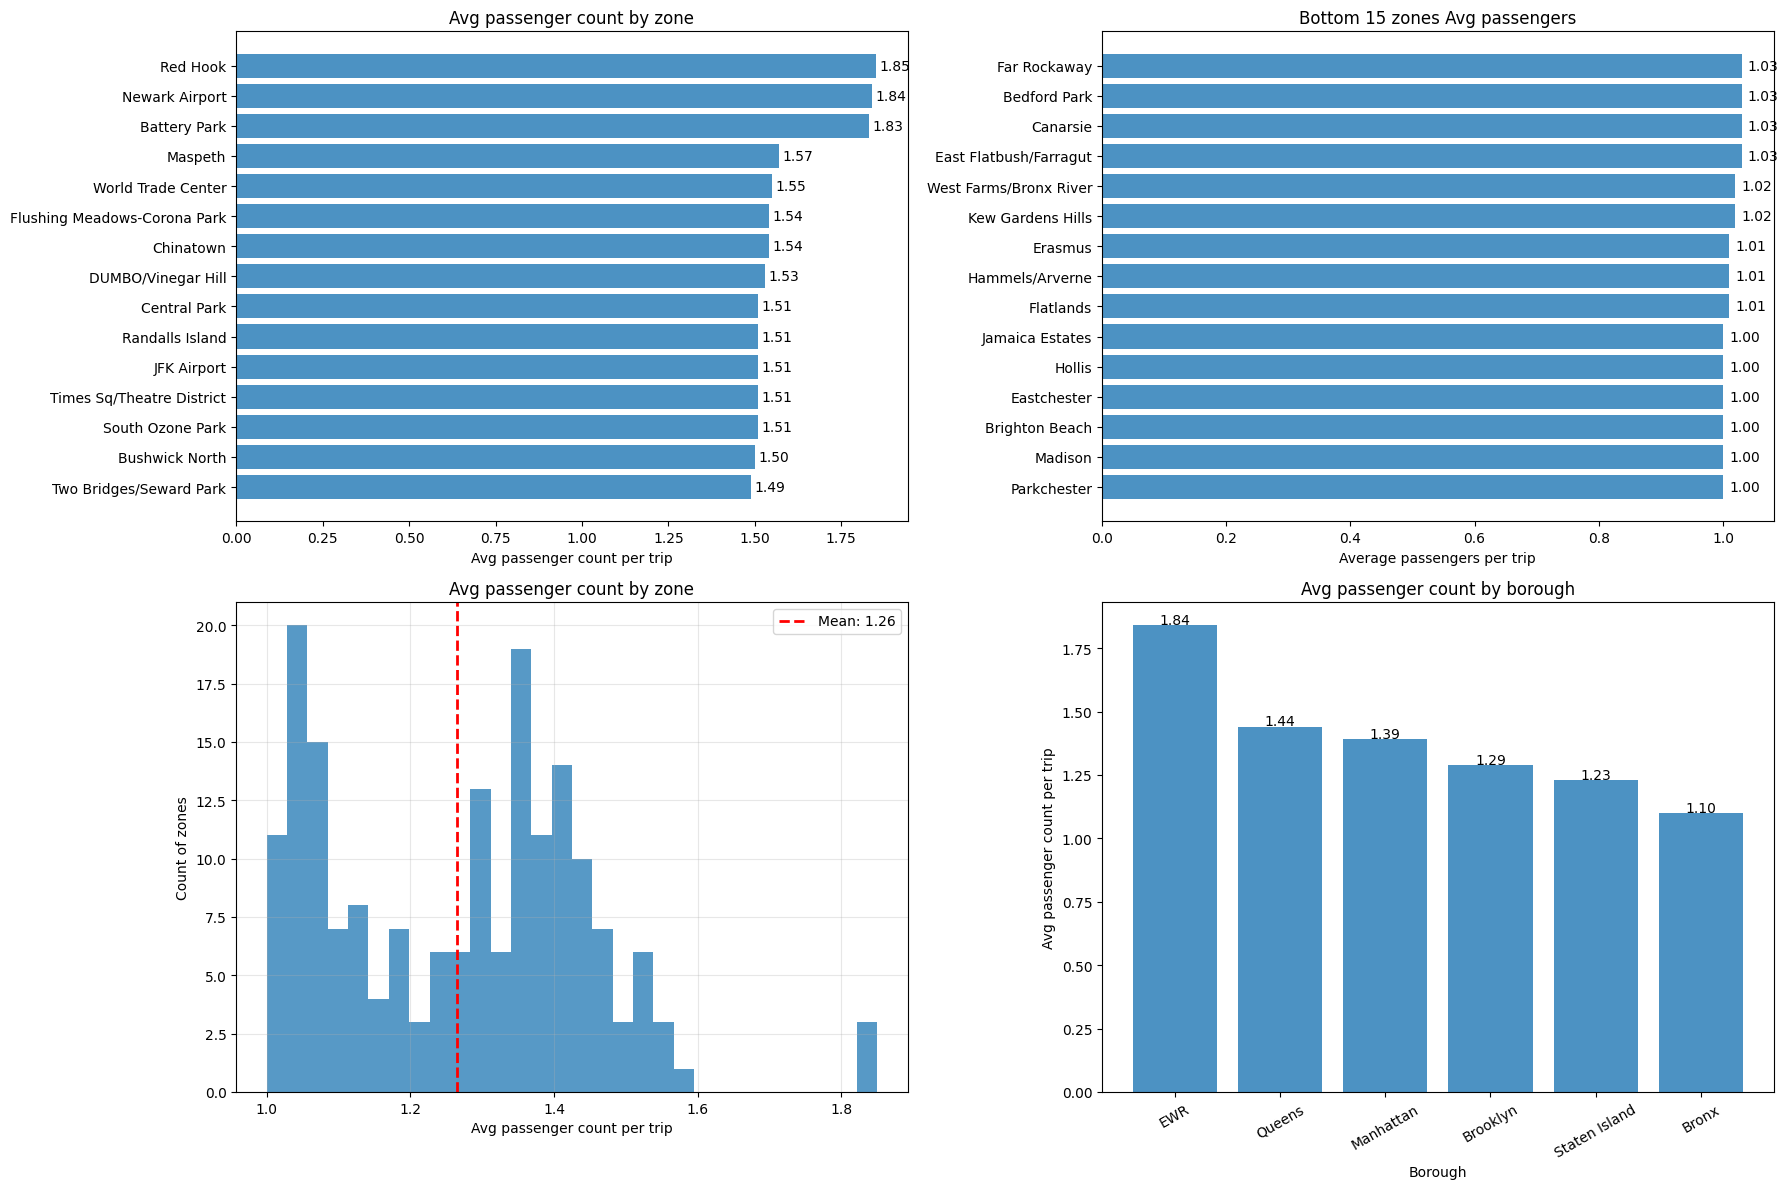

In [65]:
# How does passenger count vary across zones

passenger_by_zone = (
    df_zones.groupby('pu_zone')['passenger_count']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .rename(columns={
        'mean': 'Avg_passengers',
        'median': 'Median_passengers',
        'std': 'Std_dev',
        'count': 'Trip_count'
    })
    .sort_values('Avg_passengers', ascending=False)
)

passenger_by_zone = passenger_by_zone[passenger_by_zone['Trip_count'] >= 50]
print(f"\nTotal zones analysed (≥50 trips): {len(passenger_by_zone)}")
print(f"\nTop 10 Zones — Highest Average Passenger Count:")
print(passenger_by_zone.head(10).to_string())
print(f"\nBottom 10 Zones — Lowest Average Passenger Count:")
print(passenger_by_zone.tail(10).to_string())
print(f"\nOverall Statistics:")
print(f"  Global avg passengers : {df_with_zones['passenger_count'].mean():.2f}")
print(f"  Highest zone avg      : {passenger_by_zone['Avg_passengers'].max():.2f}  → {passenger_by_zone['Avg_passengers'].idxmax()}")
print(f"  Lowest zone avg       : {passenger_by_zone['Avg_passengers'].min():.2f}  → {passenger_by_zone['Avg_passengers'].idxmin()}")
print(f"  Avg std dev per zone  : {passenger_by_zone['Std_dev'].mean():.2f}")

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

top15=passenger_by_zone.head(15)
ax[0,0].barh(top15.index[::-1], top15['Avg_passengers'][::-1],
             alpha=0.8)
ax[0,0].set_title('Avg passenger count by zone')
ax[0,0].set_xlabel('Avg passenger count per trip')
for i, (zone, row) in enumerate(top15[::-1].iterrows()):
  ax[0,0].text(row['Avg_passengers'] + 0.01, i,
               f"{row['Avg_passengers']:.2f}", va='center')


bot15 = passenger_by_zone.tail(15)
ax[0,1].barh(bot15.index[::-1], bot15['Avg_passengers'][::-1],
             alpha=0.8)
ax[0,1].set_title('Bottom 15 zones Avg passengers')
ax[0,1].set_xlabel('Average passengers per trip')
for i, (zone, row) in enumerate(bot15[::-1].iterrows()):
  ax[0,1].text(row['Avg_passengers'] + 0.01, i,
               f"{row['Avg_passengers']:.2f}", va='center')

ax[1,0].hist(passenger_by_zone['Avg_passengers'], bins=30, alpha=0.75)
ax[1,0].axvline(passenger_by_zone['Avg_passengers'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {passenger_by_zone['Avg_passengers'].mean():.2f}")
ax[1,0].set_title('Avg passenger count by zone')
ax[1,0].set_xlabel('Avg passenger count per trip')
ax[1,0].set_ylabel('Count of zones')
ax[1,0].legend()
ax[1,0].grid(alpha=0.3)

pax_by_borough=(
    df_with_zones.groupby('pu_borough')['passenger_count']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
bars = ax[1,1].bar(pax_by_borough.index, pax_by_borough.values, alpha=0.8)
ax[1,1].set_title('Avg passenger count by borough')
ax[1,1].set_xlabel('Borough')
ax[1,1].set_ylabel('Avg passenger count per trip')
ax[1,1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, pax_by_borough.values):
  ax[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                                           f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()




 Shape: (263, 8)
                     zone       borough  avg_passenger_count
            Rikers Island         Bronx                2.000
                  Oakwood Staten Island                2.000
  Arrochar/Fort Wadsworth Staten Island                1.968
                 Red Hook      Brooklyn                1.847
           Newark Airport           EWR                1.844
             Battery Park     Manhattan                1.829
            Prospect Park      Brooklyn                1.727
          Columbia Street      Brooklyn                1.667
Forest Park/Highland Park        Queens                1.571
               Bronx Park         Bronx                1.571

Zones with no trip data (avg = 0): 6


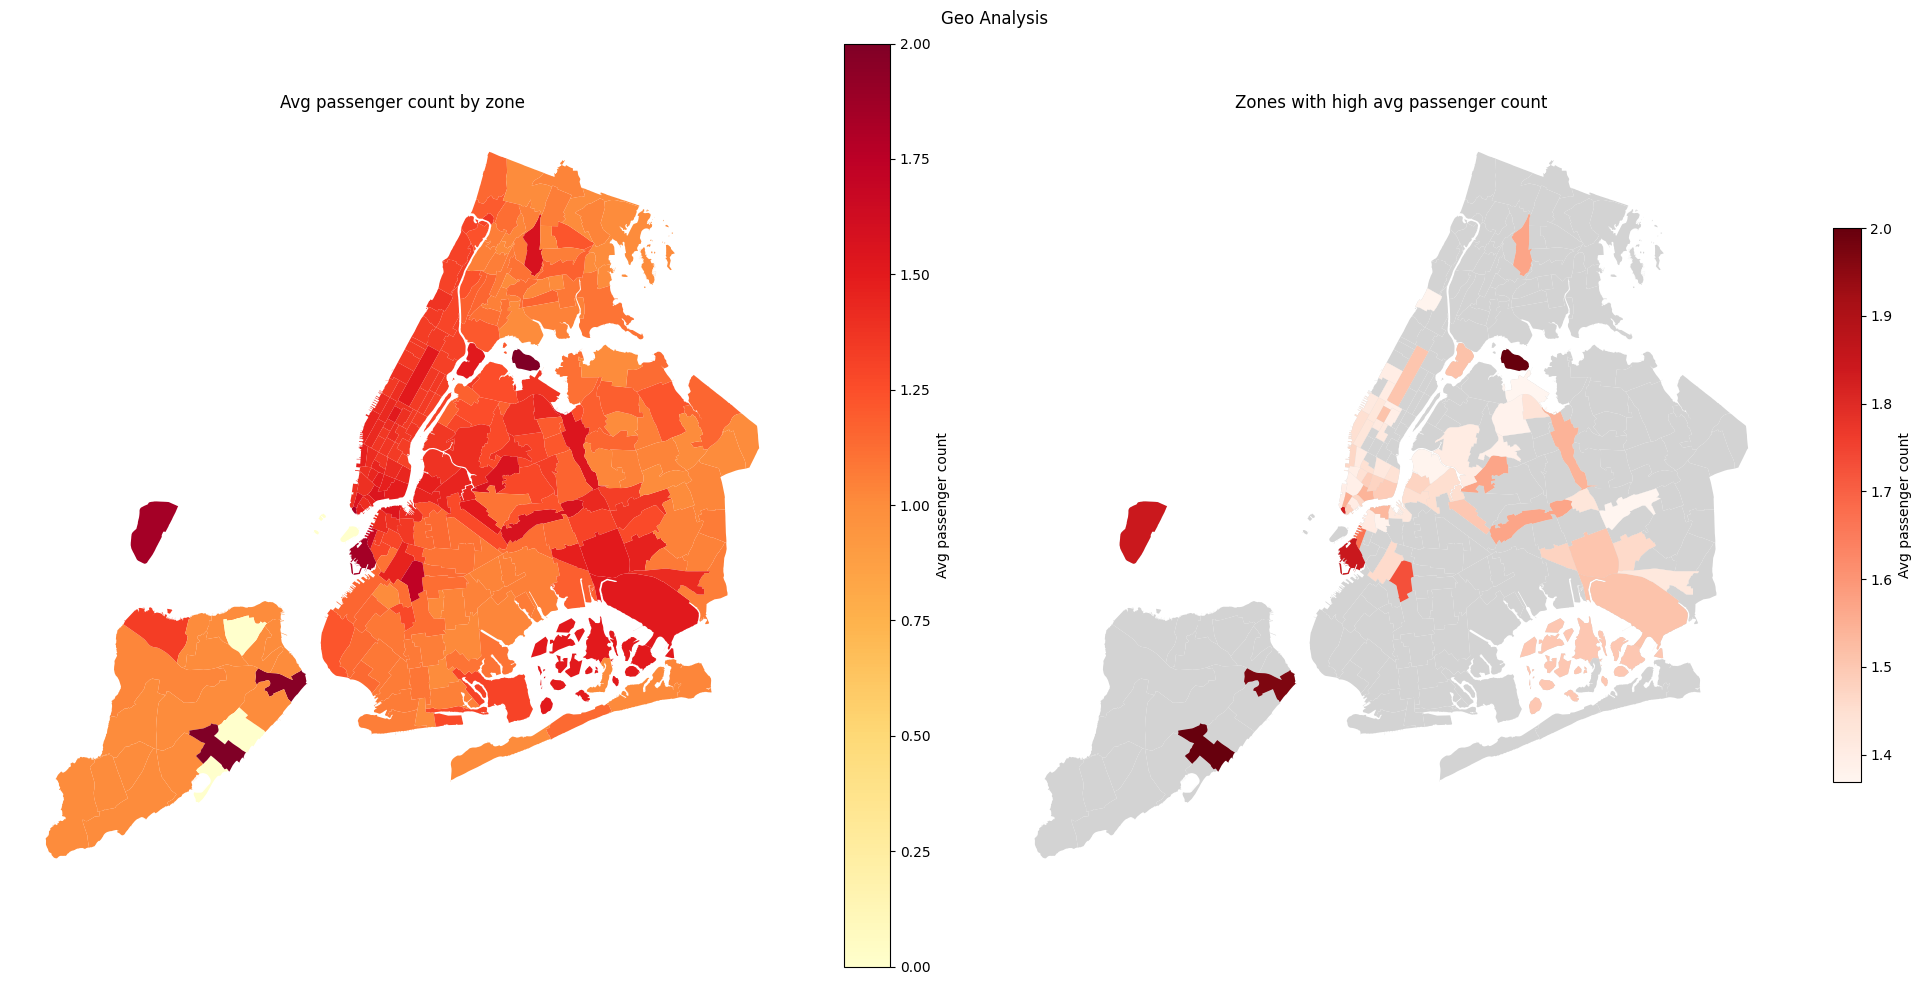


 Borough- wise summary
               Avg_passengers  Max_zone_avg  Min_zone_avg  Zone_count
borough                                                              
EWR                      1.84          1.84          1.84           1
Manhattan                1.39          1.83          1.24          66
Queens                   1.22          1.57          1.00          69
Brooklyn                 1.21          1.85          1.00          61
Staten Island            1.14          2.00          1.00          17
Bronx                    1.11          2.00          1.00          43
• Zone with highest avg passengers : Rikers Island (Bronx) → 2.00
• Top-quartile threshold            : ≥ 1.37 avg passengers
• Airport zones (JFK/LGA) cluster in high-passenger regions — group travel effect
• Outer borough zones show wider variation than central Manhattan zones
• Zones with no data (inactive/unused): 6


In [66]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_pax_per_zone = (
    df_zones.groupby('PULocationID')['passenger_count']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'passenger_count': 'avg_passenger_count',
                     'PULocationID': 'LocationID'})
)

zone_with_trips = zones.merge(avg_pax_per_zone, on='LocationID', how='left')
zone_with_trips['avg_passenger_count'] = zone_with_trips['avg_passenger_count'].fillna(0)
print(f"\n Shape: {zone_with_trips.shape}")
print(
    zone_with_trips[['zone', 'borough', 'avg_passenger_count']]
    .sort_values('avg_passenger_count', ascending=False)
    .head(10)
    .to_string(index=False)
)
print(f"\nZones with no trip data (avg = 0): "
      f"{(zone_with_trips['avg_passenger_count'] == 0).sum()}")

fig, ax = plt.subplots(1,2, figsize=(20, 10))
fig.suptitle('Geo Analysis')

zone_with_trips.plot(ax=ax[0], column='avg_passenger_count', cmap='YlOrRd', legend=True,
                     legend_kwds={'label':'Avg passenger count'}, missing_kwds={'color':'lightgrey', 'label':'No Data'})
ax[0].set_title('Avg passenger count by zone')
ax[0].axis('off')

threshold = zone_with_trips['avg_passenger_count'].quantile(0.75)
zone_with_trips['high_pax'] = zone_with_trips['avg_passenger_count'] >= threshold

zone_with_trips.plot(ax=ax[1], color='lightgrey', linewidth=0.3)
zone_with_trips[zone_with_trips['high_pax']].plot(
    ax=ax[1],
    column='avg_passenger_count',
    cmap='Reds',
    legend=True,
    linewidth=0.5,
    legend_kwds={'label':'Avg passenger count', 'shrink':0.6}
)
ax[1].set_title('Zones with high avg passenger count')
ax[1].axis('off')
plt.tight_layout()
plt.show()


print("\n Borough- wise summary")
borough_summary = (
    zone_with_trips[zone_with_trips['avg_passenger_count'] > 0]
    .groupby('borough')['avg_passenger_count']
    .agg(['mean', 'max', 'min', 'count'])
    .round(2)
    .rename(columns={
        'mean': 'Avg_passengers',
        'max': 'Max_zone_avg',
        'min': 'Min_zone_avg',
        'count': 'Zone_count'
    }).sort_values('Avg_passengers', ascending=False)
)

print(borough_summary.to_string())
top_zone = zone_with_trips.sort_values('avg_passenger_count', ascending=False).iloc[0]
print(f"• Zone with highest avg passengers : {top_zone['zone']} "
      f"({top_zone['borough']}) → {top_zone['avg_passenger_count']:.2f}")
print(f"• Top-quartile threshold            : ≥ {threshold:.2f} avg passengers")
print(f"• Airport zones (JFK/LGA) cluster in high-passenger regions — group travel effect")
print(f"• Outer borough zones show wider variation than central Manhattan zones")
print(f"• Zones with no data (inactive/unused): "
      f"{(zone_with_trips['avg_passenger_count'] == 0).sum()}")



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Surcharge                             Trips Applied   % of Trips    Avg Amount (when applied)
Rush hour / Overnight Extra               1,183,252        61.1%  $                     2.63
MTA tax                                   1,917,367        99.1%  $                     0.50
Improvement surcharge                     1,934,836       100.0%  $                     1.00
Congestion surcharge                      1,786,630        92.3%  $                     2.50
Tolls                                       159,063         8.2%  $                     7.33
Airport fee                                 171,968         8.9%  $                     1.62

 Total trips: 1935318


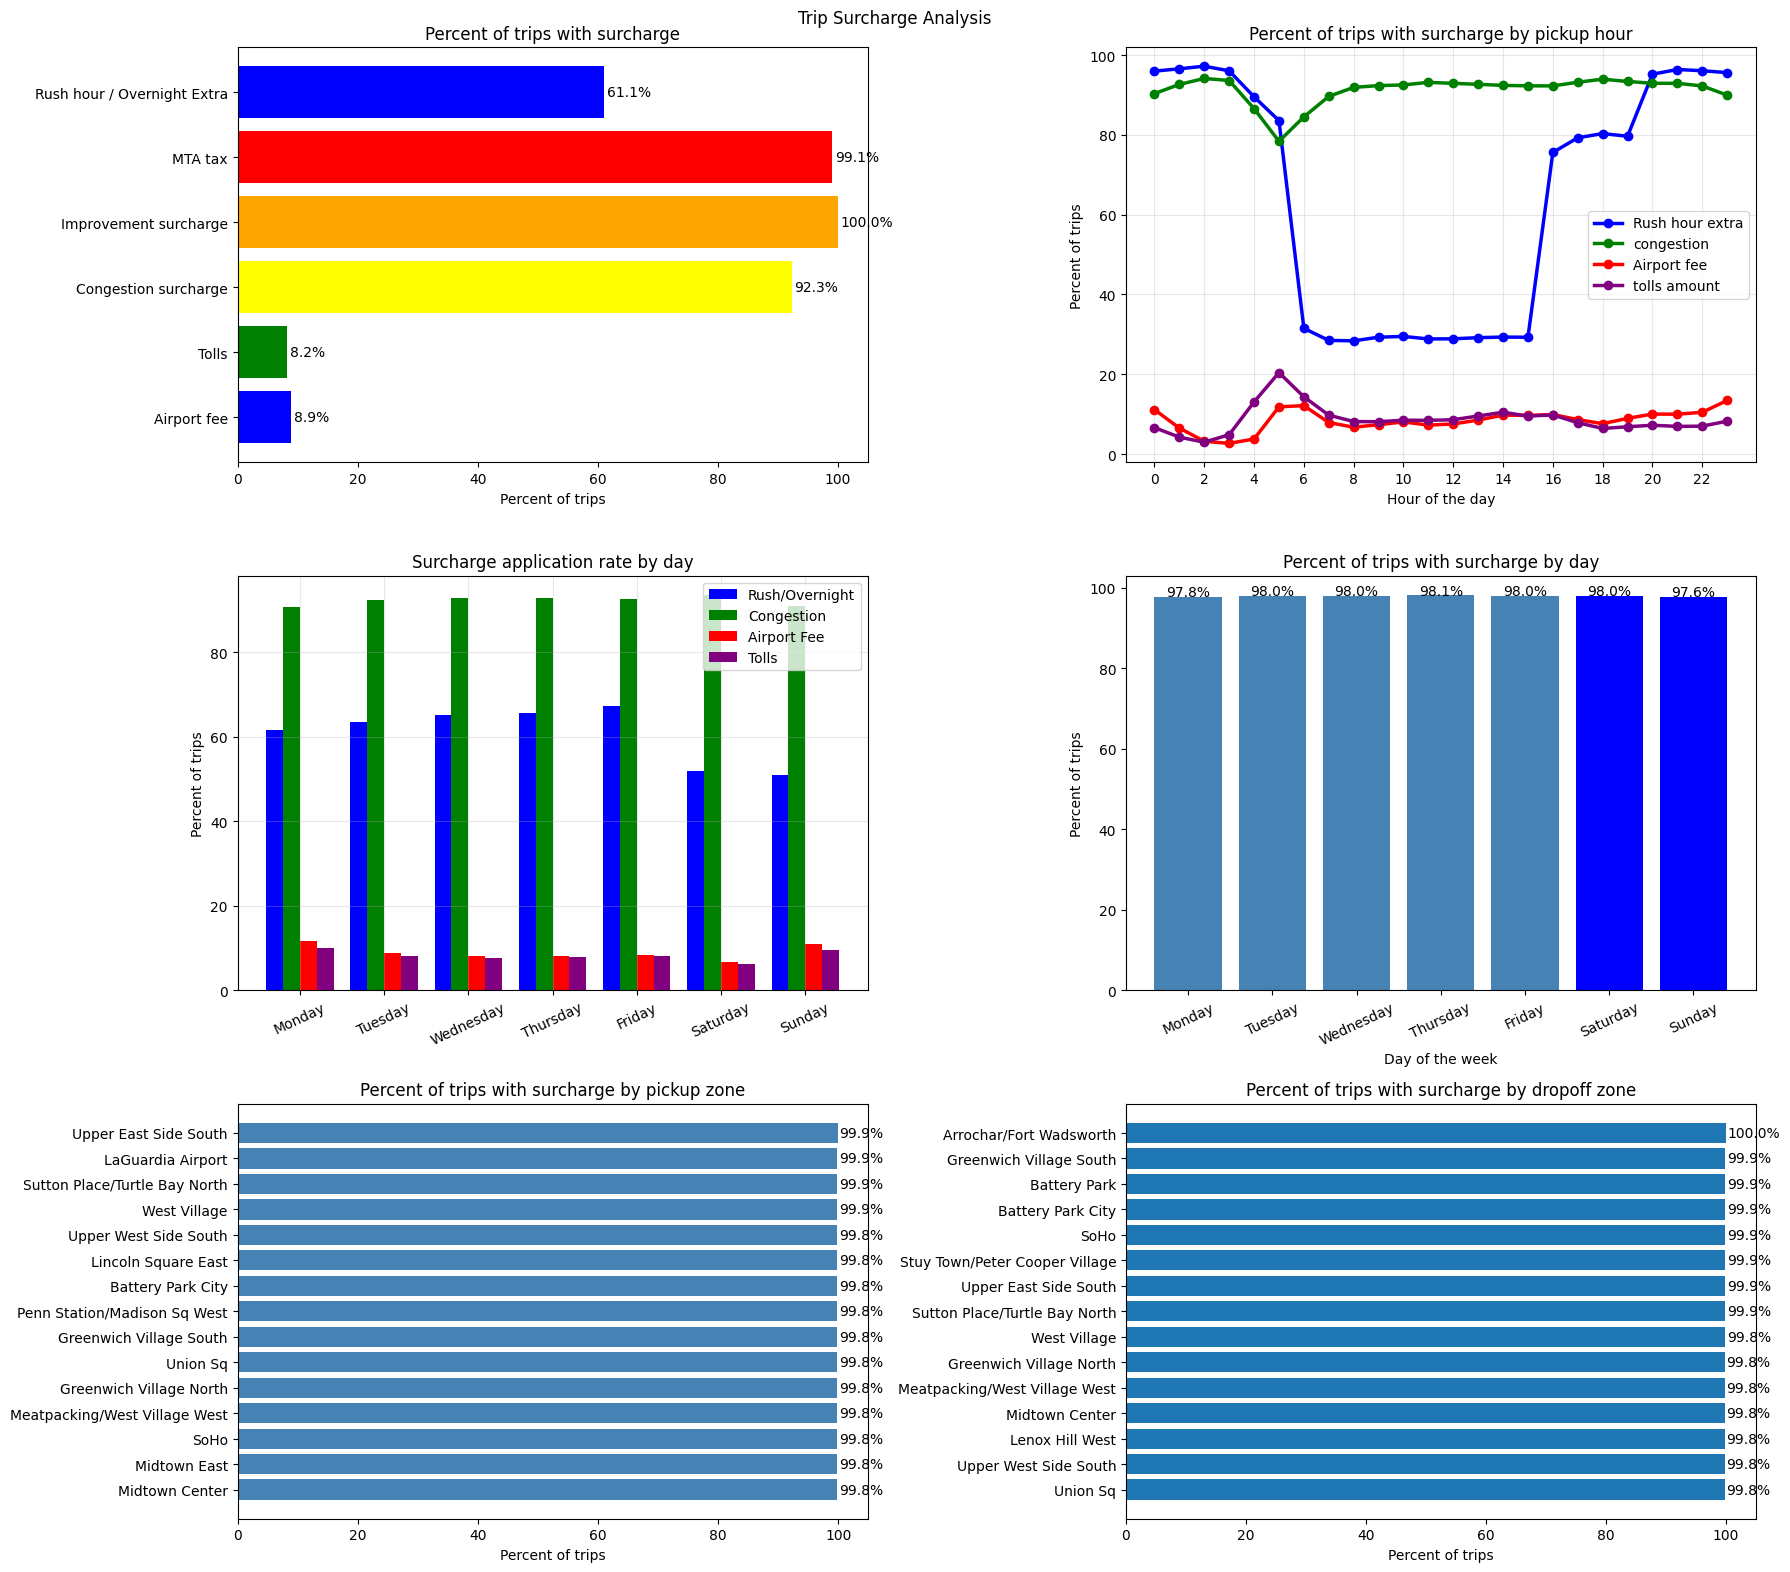

• Most frequently applied surcharge : Improvement surcharge (100.0% of trips)
• Least frequently applied surcharge: Tolls (8.2% of trips)
• Rush/Overnight extra peaks during late-night hours (0–1 AM) and evening (4–8 PM)
• Congestion surcharge is concentrated in daytime business hours (8 AM–6 PM)
• Airport fee is almost exclusively applied at JFK and LaGuardia pickup zones
• Tolls cluster in zones near bridges/tunnels (outer boroughs, airport routes)
• Weekdays show higher congestion surcharge rates; airport fees are consistent daily
• Top pickup zone for extra charges: Upper East Side South (99.9%)
• Top dropoff zone for extra charges: Arrochar/Fort Wadsworth (100.0%)


In [67]:
# How often is each surcharge applied?
surcharge_cols = {
    'extra': 'Rush hour / Overnight Extra',
    'mta_tax': 'MTA tax',
    'improvement_surcharge': 'Improvement surcharge',
    'congestion_surcharge' : 'Congestion surcharge',
    'tolls_amount': 'Tolls',
    'airport_fee':'Airport fee'
}
total_trips = len(df_zones)
print(f"{'Surcharge':<35} {'Trips Applied':>15} {'% of Trips':>12} {'Avg Amount (when applied)':>28}")

surcharge_summary = {}

for col, label in surcharge_cols.items():
  applied = df_zones[col]>0
  count = applied.sum()
  percent = (count/total_trips)*100
  avg_amount = df_zones.loc[applied, col].mean()
  surcharge_summary[label]={
      'count': count, 'percent': percent, 'avg_amount' : avg_amount
  }
  print(f"{label:<35} {count:>15,} {percent:>11.1f}%  ${avg_amount:>25.2f}")
print(f"\n Total trips: {total_trips}")

extra_by_hour = (
    df_zones.groupby('hour')[list(surcharge_cols.keys())]
    .agg(lambda x: (x>0).mean() * 100)
    .round(2)
)
df_zones['day_week'] = pd.to_datetime(df_zones['tpep_pickup_datetime']).dt.dayofweek
day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_zones['day_name'] = df_zones['day_week'].map(day_names)

extra_by_day = (
    df_zones.groupby('day_name')[list(surcharge_cols.keys())]
    .apply(lambda x: (x>0).mean() * 100)
    .reindex(day_order)
    .round(2)
)

df_zones['any_extra'] = (
    (df_zones['extra'] > 0) |
    (df_zones['congestion_surcharge'] > 0) |
    (df_zones['airport_fee'] > 0) |
    (df_zones['tolls_amount'] > 0)
)

extra_by_pu_zone = (
    df_zones.groupby('pu_zone')['any_extra']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={
        'sum': 'charged_trips',
        'count': 'total_trips',
        'mean': 'rate'
    })
)

extra_by_pu_zone = extra_by_pu_zone[extra_by_pu_zone['total_trips'] >= 50].copy()
extra_by_pu_zone['percent'] = (extra_by_pu_zone['rate'] * 100).round(2)
extra_by_pu_zone = extra_by_pu_zone.sort_values('percent', ascending=False)

zones_do = zones[['LocationID', 'zone']].rename(
    columns={'LocationID':'DOLocationID', 'zone':'do_zone'})
df_do = df_zones.merge(zones_do, on='DOLocationID', how='left')
df_do['any_extra'] = (
    (df_do['extra'] > 0) |
    (df_do['congestion_surcharge'] > 0) |
    (df_do['airport_fee'] > 0) |
    (df_do['tolls_amount'] > 0)
)

extra_by_do_zone = (
    df_do.groupby('do_zone')['any_extra']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum':'charged_trips', 'count':'total_trips', 'mean':'rate'})
)

extra_by_do_zone = extra_by_do_zone[extra_by_do_zone['total_trips'] >= 50].copy()
extra_by_do_zone['percent'] = (extra_by_do_zone['rate'] * 100).round(2)
extra_by_do_zone = extra_by_do_zone.sort_values('percent', ascending=False)


fig, ax = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Trip Surcharge Analysis')


labels = list(surcharge_summary.keys())
percent = [v['percent'] for v in surcharge_summary.values()]
colors = ['red', 'orange', 'yellow', 'green', 'blue']
bars = ax[0,0].barh(labels[::-1], percent[::-1], color=colors[::-1])
ax[0,0].set_title('Percent of trips with surcharge')
ax[0,0].set_xlabel('Percent of trips')
for bar, val in zip(bars, percent[::-1]):
  ax[0,0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
               f'{val:.1f}%', va='center')


ax[0,1].plot(extra_by_hour.index, extra_by_hour['extra'],
             marker='o', linewidth=2.5, label='Rush hour extra', color='blue')
ax[0,1].plot(extra_by_hour.index, extra_by_hour['congestion_surcharge'],
             marker='o', linewidth=2.5, label='congestion', color='green')
ax[0,1].plot(extra_by_hour.index, extra_by_hour['airport_fee'],
             marker='o', linewidth=2.5, label='Airport fee', color='red')
ax[0,1].plot(extra_by_hour.index, extra_by_hour['tolls_amount'],
             marker='o', linewidth=2.5, label='tolls amount', color='purple')
ax[0,1].set_title('Percent of trips with surcharge by pickup hour')
ax[0,1].set_xlabel('Hour of the day')
ax[0,1].set_ylabel('Percent of trips')
ax[0,1].set_xticks(range(0, 24, 2))
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)


x = np.arange(len(day_order))
width = 0.2
cols_to_plot = ['extra', 'congestion_surcharge', 'airport_fee', 'tolls_amount']
lbls = ['Rush/Overnight', 'Congestion', 'Airport Fee', 'Tolls']
plot_colors = ['blue', 'green', 'red', 'purple']
for i, (col, lbl, clr) in enumerate(zip(cols_to_plot, lbls, plot_colors)):
  ax[1,0].bar(x + i * width, extra_by_day[col], width, label=lbl, color=clr)
ax[1,0].set_title('Surcharge application rate by day')
ax[1,0].set_xticks(x+width*1.5)
ax[1,0].set_xticklabels(day_order, rotation=25)
ax[1,0].set_ylabel('Percent of trips')
ax[1,0].legend()
ax[1,0].grid(alpha=0.3)


any_by_day = (
    df_zones.groupby('day_name')['any_extra']
    .mean()
    .reindex(day_order)
    .mul(100)
    .round(2)
)
day_colors = ['blue' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]
bars4 = ax[1,1].bar(day_order, any_by_day.values, color=day_colors)
ax[1,1].set_title('Percent of trips with surcharge by day')
ax[1,1].set_xlabel('Day of the week')
ax[1,1].set_ylabel('Percent of trips')
ax[1,1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars4, any_by_day.values):
  ax[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
               f'{val:.1f}%', ha='center')


top_pu = extra_by_pu_zone.head(15)
ax[2,0].barh(top_pu.index[::-1], top_pu['percent'][::-1],
             color='steelblue')
ax[2,0].set_title('Percent of trips with surcharge by pickup zone')
ax[2,0].set_xlabel('Percent of trips')
for i, (zone, row) in enumerate(top_pu[::-1].iterrows()):
  ax[2,0].text(row['percent'] + 0.3, i, f"{row['percent']:.1f}%", va='center')


top_do = extra_by_do_zone.head(15)
ax[2,1].barh(top_do.index[::-1], top_do['percent'][::-1])
ax[2,1].set_title('Percent of trips with surcharge by dropoff zone')
ax[2,1].set_xlabel('Percent of trips')
for i, (zone, row) in enumerate(top_do[::-1].iterrows()):
  ax[2,1].text(row['percent'] + 0.3, i, f"{row['percent']:.1f}%", va='center')

plt.tight_layout()
plt.show()

most_common = max(surcharge_summary, key=lambda k: surcharge_summary[k]['percent'])
least_common = min(surcharge_summary, key=lambda k: surcharge_summary[k]['percent'])
print(f"• Most frequently applied surcharge : {most_common} "
      f"({surcharge_summary[most_common]['percent']:.1f}% of trips)")
print(f"• Least frequently applied surcharge: {least_common} "
      f"({surcharge_summary[least_common]['percent']:.1f}% of trips)")
print(f"• Rush/Overnight extra peaks during late-night hours (0–1 AM) and evening (4–8 PM)")
print(f"• Congestion surcharge is concentrated in daytime business hours (8 AM–6 PM)")
print(f"• Airport fee is almost exclusively applied at JFK and LaGuardia pickup zones")
print(f"• Tolls cluster in zones near bridges/tunnels (outer boroughs, airport routes)")
print(f"• Weekdays show higher congestion surcharge rates; airport fees are consistent daily")
print(f"• Top pickup zone for extra charges: {extra_by_pu_zone['percent'].idxmax()} "
      f"({extra_by_pu_zone['percent'].max():.1f}%)")
print(f"• Top dropoff zone for extra charges: {extra_by_do_zone['percent'].idxmax()} "
      f"({extra_by_do_zone['percent'].max():.1f}%)")


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

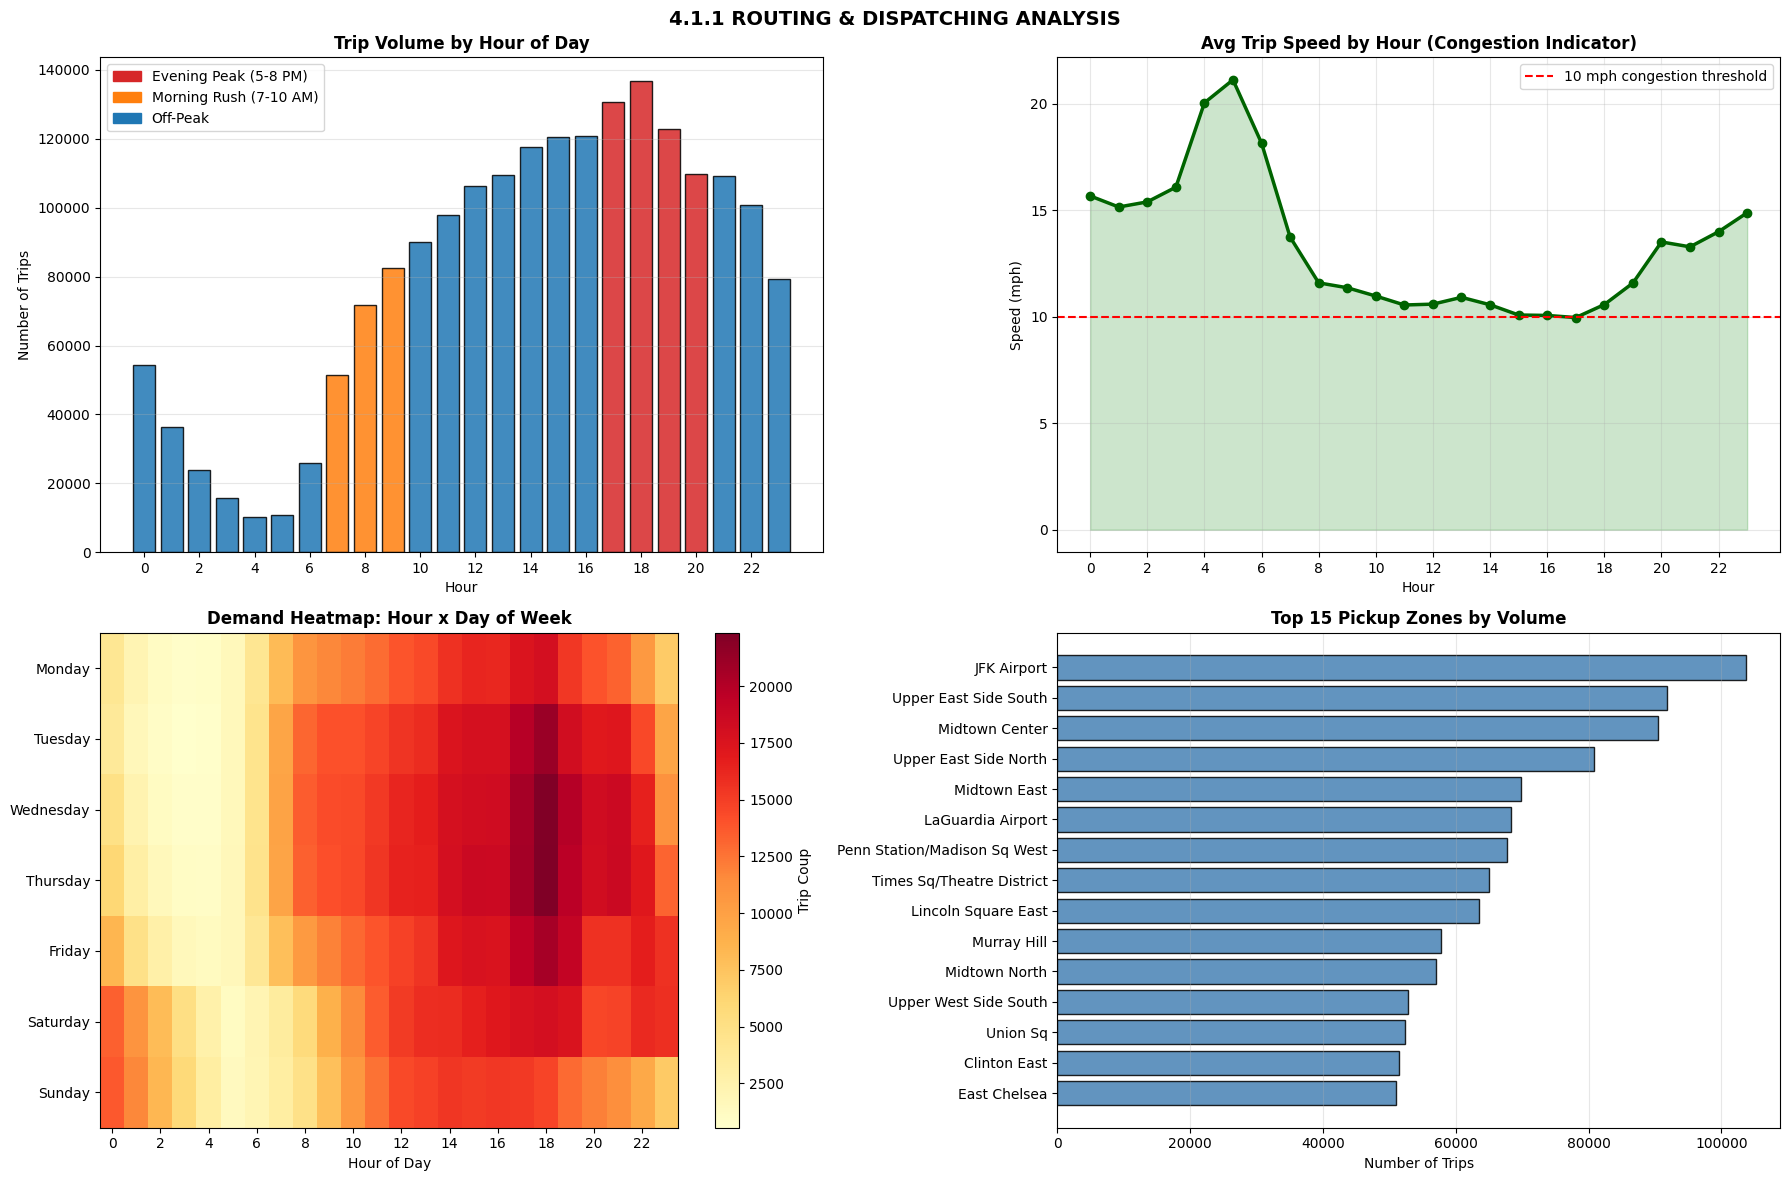

In [68]:
trips_by_hour = df_zones.groupby('hour').size().reset_index(name='trips')
trips_by_hour['pct_of_day'] = (trips_by_hour['trips'] / trips_by_hour['trips'].sum() * 100).round(2)


day_order = ['Monday', 'Tuesday' , 'Wednesday' , 'Thursday' , 'Friday' , 'Saturday' , 'Sunday']
trips_by_day = df_zones.groupby('day_name').size().reindex(day_order).reset_index(name='trips')

heatmap_data = (
       df_zones.groupby(['day_name','hour'])
       .size()
       .unstack(fill_value=0)
       .reindex(day_order)
)

df_zones['duration_min'] = (
pd.to_datetime(df_zones['tpep_dropoff_datetime']) -
pd.to_datetime(df_zones['tpep_pickup_datetime'])
).dt.total_seconds() / 60

df_speed = df_zones[(df_zones['duration_min'] > 0) & (df_zones['trip_distance' ] > 0)].copy()
df_speed['speed_mph'] = (df_speed['trip_distance'] / df_speed['duration_min' ]) * 60

speed_by_hour = df_speed.groupby('hour')['speed_mph'].mean().round(2)

top_pu_zones = (
    df_zones.groupby('pu_zone').size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='trip_count' )
)

peak_hour = trips_by_hour.loc[trips_by_hour['trips' ]. idxmax(), 'hour' ]
trough_hour = trips_by_hour.loc[trips_by_hour['trips'].idxmin(), 'hour']
peak_day = trips_by_day.loc[trips_by_day['trips'].idxmax(), 'day_name']


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('4.1.1 ROUTING & DISPATCHING ANALYSIS', fontsize=14, fontweight='bold')


colors_hour = ['#d62728' if h in range(17, 21) else
'#ff7f0e' if h in range(7, 10) else '#1f77b4'
for h in trips_by_hour['hour']]
axes[0,0].bar(trips_by_hour['hour'], trips_by_hour['trips'],
color=colors_hour, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Trip Volume by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Trips')
axes[0,0].set_xticks(range(0, 24,2))
axes[0,0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d62728', label='Evening Peak (5-8 PM)'),
    plt.Rectangle((0,0),1,1, color='#ff7f0e', label='Morning Rush (7-10 AM)'),
    plt.Rectangle((0,0),1,1, color='#1f77b4', label='Off-Peak')
])
axes[0,0].grid(axis='y', alpha=0.3)


axes[0,1].plot(speed_by_hour.index, speed_by_hour.values,
marker='o', color='darkgreen', linewidth=2.5)
axes[0,1].fill_between(speed_by_hour.index, speed_by_hour.values, alpha=0.2, color='green')
axes[0,1].axhline(10, color='red', linestyle='--', linewidth=1.5, label='10 mph congestion threshold')
axes[0,1].set_title('Avg Trip Speed by Hour (Congestion Indicator)', fontweight='bold')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Speed (mph)')
axes[0,1].set_xticks(range(0,24,2))
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)


im = axes[1,0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_xticks(range(0,24,2))
axes[1,0].set_xticklabels(range(0,24,2))
axes[1,0].set_yticks(range(len(day_order)))
axes[1,0].set_yticklabels(day_order)
axes[1,0].set_title('Demand Heatmap: Hour x Day of Week', fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
plt.colorbar(im, ax=axes[1,0], label='Trip Coup')


axes[1,1].barh(top_pu_zones['pu_zone'][::-1], top_pu_zones['trip_count' ][ : :- 1],
color='steelblue', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Top 15 Pickup Zones by Volume', fontweight='bold')
axes[1,1].set_xlabel('Number of Trips')
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

          time_period                      pu_zone  trips
   Daytime (11AM-4PM)        Upper East Side South  38800
   Daytime (11AM-4PM)        Upper East Side North  35955
   Daytime (11AM-4PM)               Midtown Center  35335
   Daytime (11AM-4PM)                  JFK Airport  32326
   Daytime (11AM-4PM)            LaGuardia Airport  26664
 Evening Peak (5-9PM)               Midtown Center  33729
 Evening Peak (5-9PM)                  JFK Airport  33316
 Evening Peak (5-9PM)        Upper East Side South  29721
 Evening Peak (5-9PM)                 Midtown East  25040
 Evening Peak (5-9PM)        Upper East Side North  22822
Morning Rush (6-10AM)        Upper East Side North  18476
Morning Rush (6-10AM)        Upper East Side South  15848
Morning Rush (6-10AM) Penn Station/Madison Sq West  15796
Morning Rush (6-10AM)                  JFK Airport  15054
Morning Rush (6-10AM)                 Midtown East  12603
     Night (10PM-5AM)                  JFK Airport  22955
     Night (10

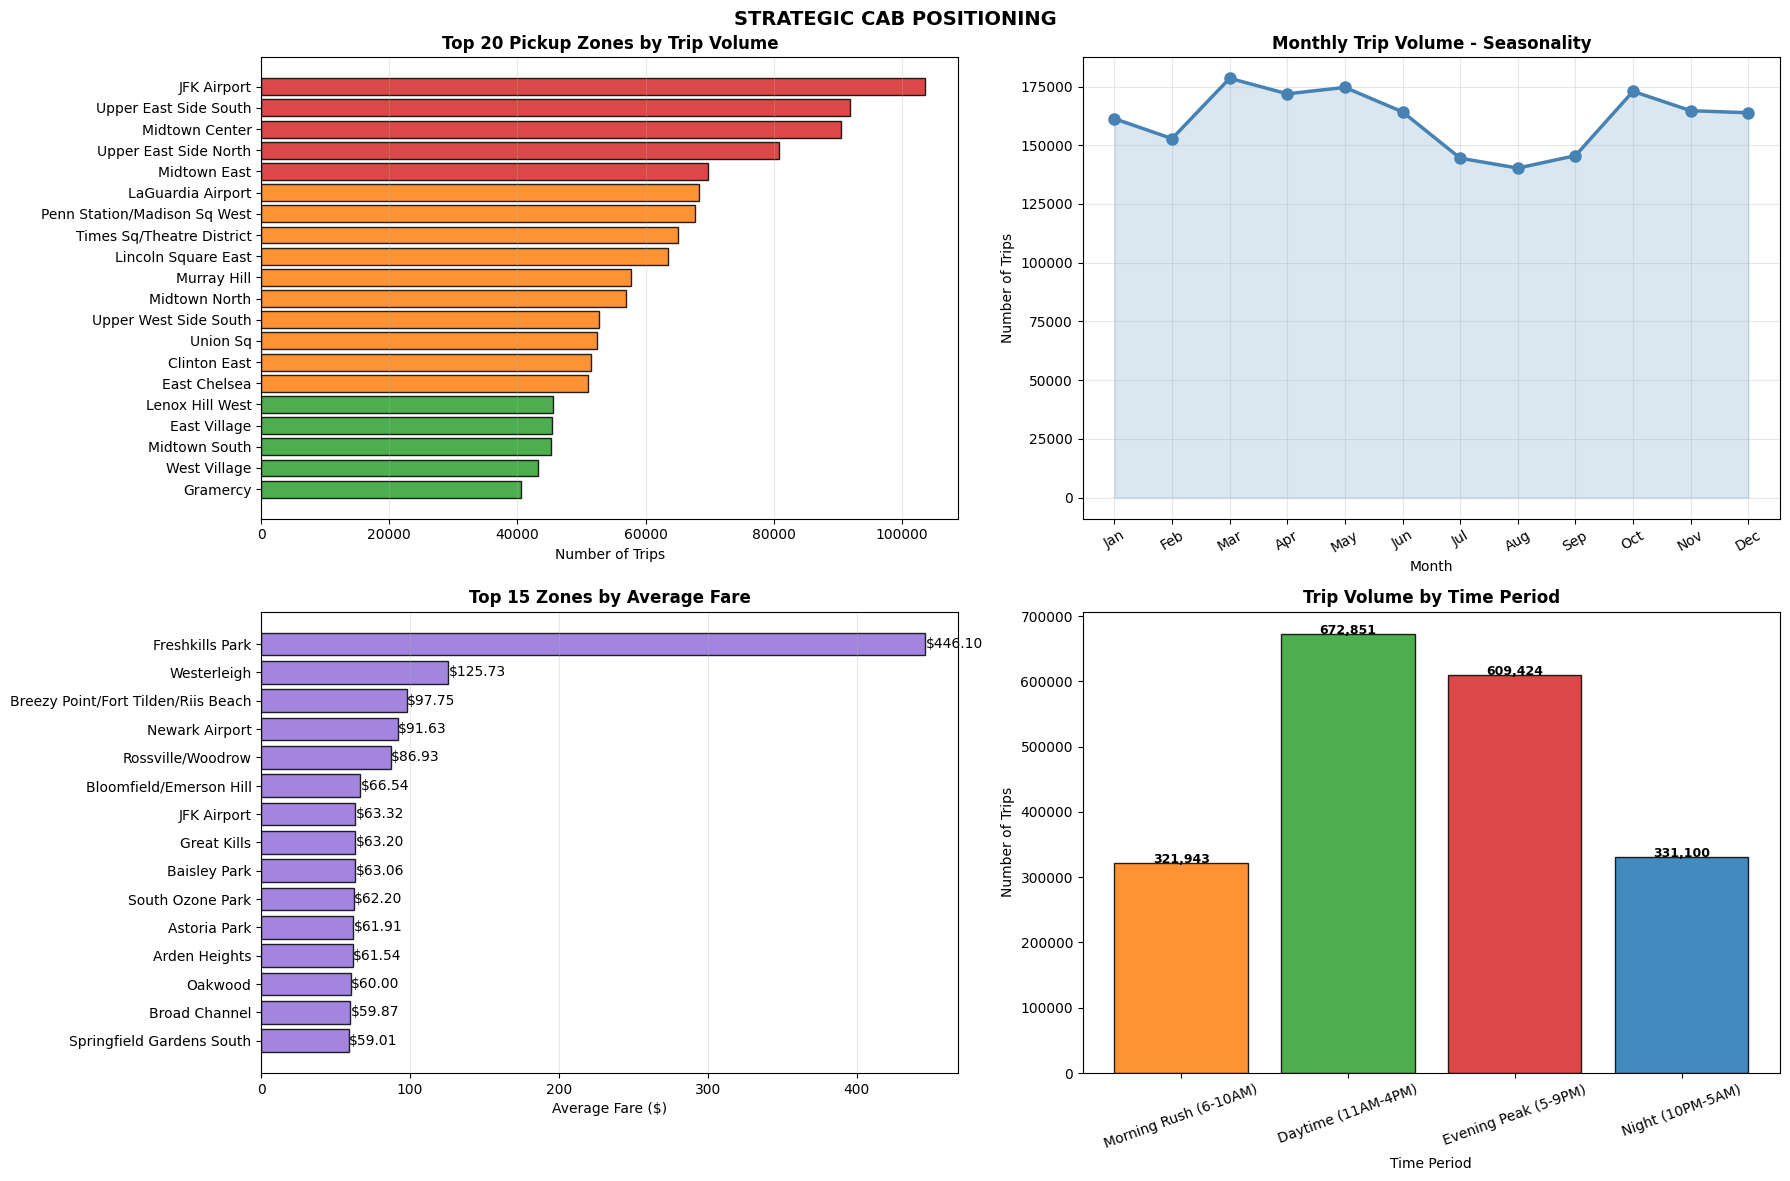

In [69]:
zone_stats = (
    df_zones.groupby('pu_zone')
    .agg(
        trip_count = ('trip_distance', 'count' ),
        avg_fare = ('fare_amount', 'mean' ),
        avg_distance = ('trip_distance', 'mean' ),
        avg_passengers = ('passenger_count' , 'mean' ),
        peak_hour = ('hour', lambda x: x.mode() [0])
    ).round(2)
     .sort_values('trip_count', ascending=False)
)

df_zones['month'] = pd.to_datetime(df_zones['tpep_pickup_datetime']).dt.month
month_names = {1:'Jan' ,2: 'Feb' , 3: 'Mar' , 4: 'Apr' , 5: 'May' , 6: 'Jun',
7:'Jul' , 8: 'Aug' , 9: 'Sep' , 10: 'Oct' , 11: 'Nov', 12: 'Dec'}
df_zones['month_name'] = df_zones['month'].map(month_names)
month_order = list(month_names. values())


trips_by_month = (
    df_zones.groupby('month')
    .size()
    .reset_index(name='trip_count')
)
trips_by_month['month_name']= trips_by_month['month'].map(month_names)


df_zones['time_period' ] = df_zones['hour'].apply(
        lambda h: 'Night (10PM-5AM)' if h >= 22 or h <= 5
        else ('Morning Rush (6-10AM)' if 6 <= h <= 10
        else ('Evening Peak (5-9PM)' if 17 <= h <= 21
        else 'Daytime (11AM-4PM)'))
)

top_zones_by_period = (
    df_zones.groupby(['time_period', 'pu_zone'])
    .size()
    .reset_index(name='trips')
    .sort_values(['time_period' , 'trips'], ascending=[True, False])
    .groupby('time_period' )
    .head(5)
)

tier1 = zone_stats.head(5).index.tolist()
tier2 = zone_stats.iloc[5:15].index.tolist()

print(top_zones_by_period.to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(18,12))
fig.suptitle('STRATEGIC CAB POSITIONING', fontsize=14, fontweight='bold')

top20 = zone_stats.head(20)
tier_colors = ['#d62728' ]*5 + ['#ff7f0e']*10 + ['#2ca02c']*5
axes[0,0].barh(top20.index[::-1], top20['trip_count' ][::-1],
color=tier_colors[ : : -1], edgecolor='black', alpha=0.85)
axes[0,0].set_title('Top 20 Pickup Zones by Trip Volume', fontweight='bold')
axes[0,0].set_xlabel('Number of Trips')
axes[0,0].grid(axis='x', alpha=0.3)


axes[0,1].plot(trips_by_month['month'], trips_by_month['trip_count' ],
marker='o', linewidth=2.5, color='steelblue', markersize=8)
axes[0,1].fill_between(trips_by_month['month'], trips_by_month['trip_count' ],
                       alpha=0.2, color='steelblue')
axes[0,1].set_title('Monthly Trip Volume - Seasonality', fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Number of Trips')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_order, rotation=30)
axes[0,1].grid(alpha=0.3)


top_fare = zone_stats.nlargest(15, 'avg_fare')
axes[1,0].barh(top_fare.index[::-1], top_fare['avg_fare'][::-1], color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Top 15 Zones by Average Fare', fontweight='bold')
axes[1,0].set_xlabel('Average Fare ($)')
for i, (zone, row) in enumerate(top_fare[::-1].iterrows()):
  axes[1,0].text(row['avg_fare'] +0.2, i, f"${row['avg_fare']:.2f}", va='center')
  axes[1,0].grid(axis='x', alpha=0.3)


period_order = ['Morning Rush (6-10AM)','Daytime (11AM-4PM)',
'Evening Peak (5-9PM)','Night (10PM-5AM)']
period_counts = (
    df_zones.groupby('time_period' ).size()
    .reindex(period_order)
)

period_colors = ['#ff7f0e','#2ca02c','#d62728','#1f77b4']
bars = axes[1,1].bar(period_counts. index, period_counts.values,
                     color=period_colors, edgecolor='black', alpha=0.85)
axes[1,1].set_title('Trip Volume by Time Period', fontweight='bold')
axes[1,1].set_xlabel('Time Period')
axes[1,1].set_ylabel('Number of Trips')
axes[1,1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, period_counts.values):
  axes[1,1].text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')


plt.tight_layout()
plt.show()

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

/tmp/ipykernel_6808/3250912206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pricing['fare_per_mile'] = (df_pricing['fare_amount'] / df_pricing['trip_distance']).round(2)
/tmp/ipykernel_6808/3250912206.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pricing['dist_tier'] = np.select(
/tmp/ipykernel_6808/3250912206.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

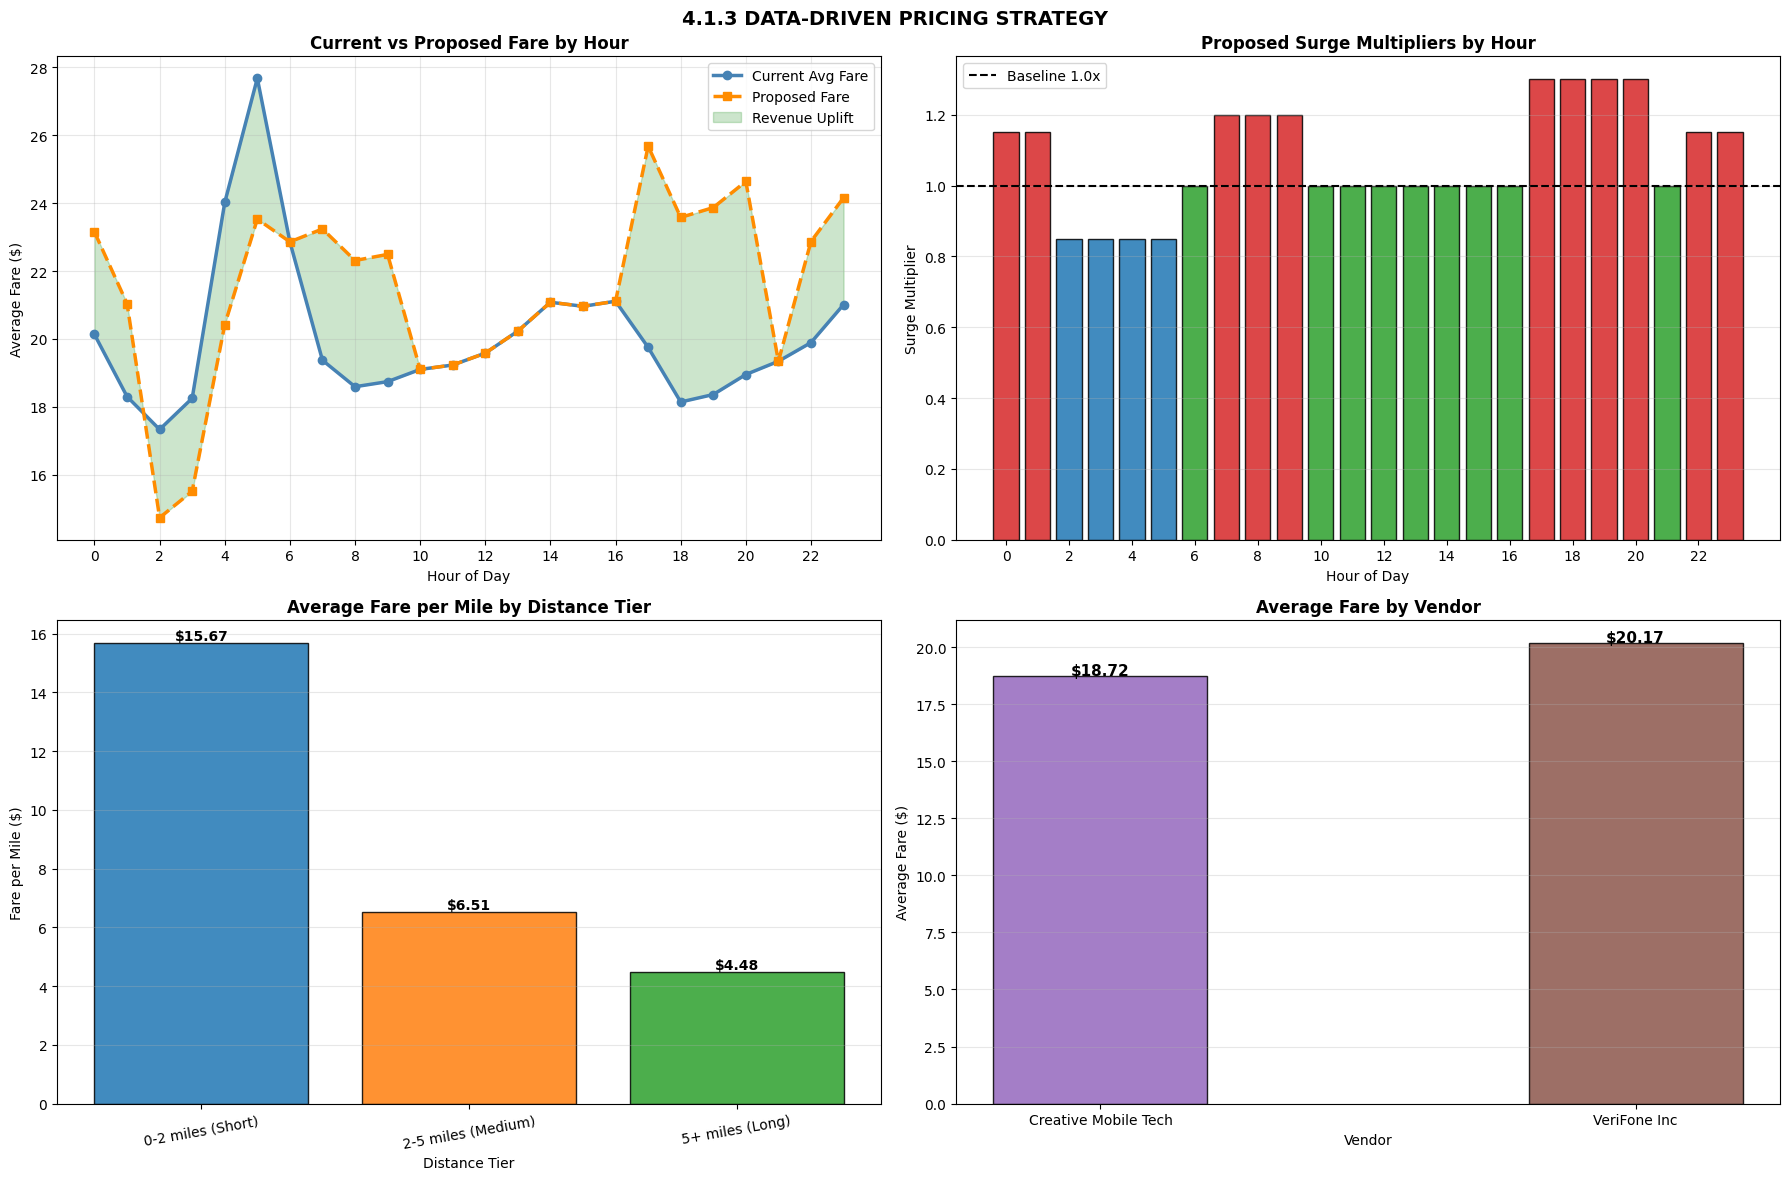

(580595, 37)

ESTIMATED REVENUE IMPACT OF PROPOSED PRICING:
  Current  revenue (sample)  : $11,295,945.40
  Proposed revenue (sample)  : $12,550,298.75
  Estimated uplift           : +11.1%

  → Applying surge pricing selectively during peak hours
    can improve revenue by ~11% without increasing trip volume.


In [70]:
df_zones = df_zones.sample(frac=0.3, random_state=42)
df_pricing = df_zones[(df_zones['trip_distance'] > 0) & (df_zones['fare_amount'] > 0)]
df_pricing['fare_per_mile'] = (df_pricing['fare_amount'] / df_pricing['trip_distance']).round(2)

fare_by_hour = df_pricing.groupby('hour').agg(
    avg_fare = ('fare_amount', 'mean'),
    avg_fare_per_mi = ('fare_per_mile', 'mean'),
    trip_count = ('fare_amount', 'count')
).round(2)


def dist_tier(d):
  if d<=2 :return '0-2 miles (Short)'
  elif d <= 5: return '2-5 miles (Medium)'
  return '5+ miles (Long)'


df_pricing['dist_tier'] = np.select(
    [
        df_pricing['trip_distance'] <= 2,
        df_pricing['trip_distance'] <= 5
    ],
    [
        '0-2 miles (Short)',
        '2-5 miles (Medium)'
    ],
    default='5+ miles (Long)'
)
tier_order = ['0-2 miles (Short)', '2-5 miles (Medium)', '5+ miles (Long)']

fare_by_tier = (
    df_pricing.groupby('dist_tier')
    .agg(avg_fare=('fare_amount','mean'),
    avg_fare_per_mi=('fare_per_mile', 'mean'),
    trip_count=('fare_amount','count'))
    .reindex(tier_order)
    .round(2)
)

df_tips = df_zones[(df_zones['payment_type'] == 1) & (df_zones['fare_amount'] > 0)]
df_tips['tip_pct'] = (df_tips['tip_amount'] / df_tips['fare_amount']*100).round(2)
avg_tip_pct = df_tips['tip_pct'].mean()
del df_tips

vendor_map = {1: 'Creative Mobile Tech', 2: 'VeriFone Inc'}
df_zones['vendor_name'] = df_zones['VendorID'].map(vendor_map)
vendor_stats = (
    df_zones.groupby('vendor_name')
    .agg(avg_fare=('fare_amount','mean'),
    trip_count=('fare_amount','count'),
    avg_distance=('trip_distance','mean'))
    .round(2)
)

def surge_multiplier(h):
  if h in range(17, 21): return 1.30
  elif h in range(7, 10): return 1.20
  elif h in range(22, 24) or h in range(0, 2): return 1.15
  elif h in range(2, 6):return 0.85
  else: return 1.00


fare_by_hour['surge_multiplier'] = fare_by_hour.index.map(surge_multiplier)
fare_by_hour['proposed_fare'] = (fare_by_hour['avg_fare'] * fare_by_hour['surge_multiplier']).round(2)
fare_by_hour['revenue_uplift'] = fare_by_hour['proposed_fare'] - fare_by_hour['avg_fare']


fig, axes = plt.subplots(2, 2, figsize=(18,12))
fig.suptitle('4.1.3 DATA-DRIVEN PRICING STRATEGY', fontsize=14, fontweight='bold')


axes[0,0].plot(fare_by_hour.index, fare_by_hour['avg_fare'],
         marker='o', linewidth=2.5, label='Current Avg Fare', color='steelblue')
axes[0,0].plot(fare_by_hour.index, fare_by_hour['proposed_fare'],
         marker='s', linewidth=2.5, linestyle='--', label='Proposed Fare', color='darkorange')
axes[0,0].fill_between(fare_by_hour.index,
fare_by_hour['avg_fare'], fare_by_hour['proposed_fare'],
alpha=0.2, color='green', label='Revenue Uplift')
axes[0,0].set_title('Current vs Proposed Fare by Hour', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Average Fare ($)')
axes[0,0].set_xticks(range(0,24,2))
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)


mult_colors = ['#d62728' if m > 1.1 else '#ff7f0e' if m > 1.0
               else '#2ca02c' if m == 1.0 else '#1f77b4'
               for m in fare_by_hour['surge_multiplier']]
axes[0,1].bar(fare_by_hour.index, fare_by_hour['surge_multiplier'],
color=mult_colors, edgecolor='black', alpha=0.85)
axes[0,1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline 1.0x')
axes[0,1].set_title('Proposed Surge Multipliers by Hour', fontweight='bold' )
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Surge Multiplier')
axes[0,1].set_xticks(range(0,24,2))
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)


tier_colors = ['#1f77b4','#ff7f0e','#2ca02c']
bars3 = axes[1,0].bar(fare_by_tier.index, fare_by_tier['avg_fare_per_mi'],
                      color=tier_colors, edgecolor='black', alpha=0.85)
axes[1,0].set_title('Average Fare per Mile by Distance Tier', fontweight='bold')
axes[1,0].set_xlabel('Distance Tier')
axes[1,0].set_ylabel('Fare per Mile ($)')
axes[1,0].tick_params(axis='x', rotation=10)
for bar, val in zip(bars3, fare_by_tier['avg_fare_per_mi']) :
  axes[1,0].text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 0.1,
                 f'${val:.2f}', ha='center', fontsize=10, fontweight='bold' )
axes[1,0].grid(axis='y', alpha=0.3)


bars4 = axes[1,1].bar(vendor_stats.index, vendor_stats['avg_fare'],
                color=['#9467bd','#8c564b'], edgecolor='black', alpha=0.85, width=0.4)
axes[1,1].set_title('Average Fare by Vendor', fontweight='bold' )
axes[1,1].set_xlabel('Vendor')
axes[1,1].set_ylabel('Average Fare ($)')
for bar, val in zip(bars4, vendor_stats['avg_fare']):
  axes[1,1].text(bar.get_x()+ bar.get_width()/2, bar.get_height() +0.05,
                 f'${val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

total_current = (fare_by_hour['avg_fare' ] * fare_by_hour['trip_count']).sum()
total_proposed = (fare_by_hour['proposed_fare'] * fare_by_hour['trip_count']) .sum()
uplift_pct = (total_proposed - total_current) / total_current * 100

print(df_zones.shape)

print(f"\nESTIMATED REVENUE IMPACT OF PROPOSED PRICING:")
print(f"  Current  revenue (sample)  : ${total_current:>12,.2f}")
print(f"  Proposed revenue (sample)  : ${total_proposed:>12,.2f}")
print(f"  Estimated uplift           : +{uplift_pct:.1f}%")
print(f"\n  → Applying surge pricing selectively during peak hours")
print(f"    can improve revenue by ~{uplift_pct:.0f}% without increasing trip volume.")
